# GRU Model for WTI Direction Forecasting

This notebook trains Gated Recurrent Unit (GRU) neural network classifiers to predict the next-day direction of WTI crude oil prices. I compare several feature specifications: a baseline macro/price model, a CFTC/COT-augmented model, an HMM regime-feature model, and a regime-specific modeling approach.

Unlike the ELM and gradient boosting models, the GRU uses short rolling sequences of predictors. Each prediction is based on the previous `lookback` days of features, allowing the model to learn temporal patterns in macroeconomic, price-derived, COT, and regime-related variables.

It's important to note that everything until the "Final Runs" are not included in the paper due to the dates changing based on COT data. I used the same tuned hyperparameters on the final runs that I found in the prelimary runs.

In [210]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix, recall_score, f1_score
import seaborn as sns
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler
import os

## 1. Load Chronological Train, Validation, and Test Splits

The train, validation, and test files were created using chronological splits. This is necessary for a time-series forecasting problem because shuffling observations would allow future market conditions to influence earlier training observations.

I recompute log returns from WTI prices so strategy evaluation uses a consistent realized-return series.

In [145]:
train_df = pd.read_csv("train_final.csv")
val_df = pd.read_csv("val_final.csv")
test_df = pd.read_csv("test_final.csv")

for df in [train_df, val_df, test_df]:
    df["returns"] = np.log(df["Price"]).diff()
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)

for df in [train_df, val_df, test_df]:
    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)
    df.reset_index(drop=True, inplace=True)

print(train_df.shape, val_df.shape, test_df.shape)
print(train_df["Date"].min(), train_df["Date"].max())
print(val_df["Date"].min(), val_df["Date"].max())
print(test_df["Date"].min(), test_df["Date"].max())

(1742, 50) (528, 50) (474, 50)
2015-05-24 00:00:00 2021-12-31 00:00:00
2022-01-04 00:00:00 2023-12-29 00:00:00
2024-01-03 00:00:00 2025-10-31 00:00:00


## 2. Define Baseline Feature Set

The baseline GRU excludes non-predictive columns such as date, price, realized returns, and the target label. Regime labels and regime probabilities are also excluded from the baseline so it can be compared fairly against later regime-enhanced specifications.

In [146]:
target_col = "Target"

baseline_exclude_cols = [
    "Date",
    "Price",
    "returns",
    "Target",
    "regime",
    "regime_prob_0",
    "regime_prob_1",
    "regime_prob_2"
]

feature_cols = [c for c in train_df.columns if c not in baseline_exclude_cols]

print("Number of baseline features:", len(feature_cols))
print(feature_cols)

Number of baseline features: 42
['RPI', 'W875RX1', 'CMRMTSPLx', 'IPFPNSS', 'USWTRADE', 'USTRADE', 'BUSLOANS', 'CONSPI', 'S&P 500', 'S&P PE ratio', 'FEDFUNDS', 'TB3MS', 'TB6MS', 'GS1', 'GS5', 'GS10', 'AAA', 'BAA', 'TB3SMFFM', 'TB6SMFFM', 'T1YFFM', 'T5YFFM', 'T10YFFM', 'AAAFFM', 'BAAFFM', 'EXSZUSx', 'EXJPUSx', 'EXUSUKx', 'EXCAUSx', 'PPICMM', 'UMCSENTx', 'net_position', 'net_position_pct', 'flow', 'long_short_ratio', 'Open_Interest_All', 'oi_change', 'vol_20', 'momentum_20', 'vol_60', 'drawdown', 'trend']


## 3. Build Rolling GRU Sequences

The GRU requires three-dimensional input with shape `(samples, lookback, features)`. For each target date, the model uses the previous `lookback` rows of features to predict the current target. This setup avoids using same-day realized information in the prediction.

I used a 10 day lookback and not 30 days like I did in the original implementation. This is due to my dataset shrinking. I wanted to make sure my lookback window was not too large when I did per-regime modeling later as some of the regimes are small.

In [147]:
lookback = 10

def make_sequences(df, feature_cols, target_col="Target", lookback=10):
    X = []
    y = []
    meta_rows = []

    values = df[feature_cols].values.astype(np.float32)
    targets = df[target_col].values.astype(np.float32)

    for i in range(lookback, len(df)):
        X.append(values[i-lookback:i])
        y.append(targets[i])

        meta_rows.append({
            "Date": df["Date"].iloc[i],
            "Price": df["Price"].iloc[i],
            "returns": df["returns"].iloc[i],
            "vol_20": df["vol_20"].iloc[i],
            "Target": df[target_col].iloc[i]
        })

    return np.array(X), np.array(y), pd.DataFrame(meta_rows)

The code below converts the baseline train, validation, and test dataframes into rolling GRU sequences.

In [148]:
X_train_seq, y_train_seq, train_meta = make_sequences(train_df, feature_cols, target_col, lookback)
X_val_seq, y_val_seq, val_meta = make_sequences(val_df, feature_cols, target_col, lookback)
X_test_seq, y_test_seq, test_meta = make_sequences(test_df, feature_cols, target_col, lookback)

print(X_train_seq.shape, y_train_seq.shape)
print(X_val_seq.shape, y_val_seq.shape)
print(X_test_seq.shape, y_test_seq.shape)

(1732, 10, 42) (1732,)
(518, 10, 42) (518,)
(464, 10, 42) (464,)


## 4. Scale Sequence Features Using Training Data Only

The scaler is fit only on the training sequences and then applied to validation or test sequences. The sequence arrays are temporarily reshaped into two dimensions for scaling and then reshaped back into GRU format. This avoids fitting preprocessing steps on validation or test data.

In [149]:
def fit_transform_sequence_scaler(X_train, X_other):
    n_train, t, f = X_train.shape
    n_other = X_other.shape[0]

    scaler = StandardScaler()

    X_train_2d = X_train.reshape(-1, f)
    X_other_2d = X_other.reshape(-1, f)

    X_train_scaled = scaler.fit_transform(X_train_2d).reshape(n_train, t, f)
    X_other_scaled = scaler.transform(X_other_2d).reshape(n_other, t, f)

    return X_train_scaled, X_other_scaled, scaler

## 5. GRU Neural Network Architecture

The GRU model processes each rolling feature sequence and uses the final hidden state to predict the probability of an upward WTI move. The architecture includes a GRU layer followed by a linear output layer. The model outputs logits during training and probabilities during prediction.

In [150]:
class UnifiedGRU(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.0):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_size, 1)

        self.train_losses = []
        self.val_losses = []

    def forward(self, x):
        out, _ = self.gru(x)
        last_hidden = out[:, -1, :]
        logits = self.fc(last_hidden).squeeze(1)
        return logits

## 6. GRU Training Function

This helper trains the GRU using binary cross-entropy with logits. Validation loss is tracked for early stopping so the model does not continue training after validation performance stops improving.

In [ ]:
def train_gru(
    X_train,
    y_train,
    X_val=None,
    y_val=None,
    hidden_size=32,
    num_layers=1,
    dropout=0.0,
    learning_rate=0.001,
    batch_size=32,
    num_epochs=50,
    patience=7,
    random_state=42,
    verbose=True
):
    torch.manual_seed(random_state)
    np.random.seed(random_state)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = UnifiedGRU(
        input_size=X_train.shape[2],
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout
    ).to(device)

    # Binary cross-entropy with logits is used because the model outputs raw logits.
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    train_ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32)
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False)

    best_state = None
    best_val_loss = np.inf
    patience_count = 0

    if X_val is not None:
        X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
        y_val_t = torch.tensor(y_val, dtype=torch.float32).to(device)

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        total_n = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_n += xb.size(0)

        train_loss = total_loss / total_n
        model.train_losses.append(train_loss)

        if X_val is not None:
            model.eval()
            with torch.no_grad():
                val_logits = model(X_val_t)
                val_loss = criterion(val_logits, y_val_t).item()

            model.val_losses.append(val_loss)

            if verbose:
                print(
                    f"Epoch {epoch+1}/{num_epochs} | "
                    f"Train Loss: {train_loss:.4f} | "
                    f"Val Loss: {val_loss:.4f}"
                )

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                patience_count = 0
            else:
                patience_count += 1

            if patience_count >= patience:
                if verbose:
                    print("Early stopping triggered.")
                break
        else:
            if verbose:
                print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

The prediction helper converts GRU logits into probabilities using the sigmoid function. These probabilities are interpreted as the predicted probability of an upward WTI move.

In [9]:
def predict_gru_proba(model, X):
    device = next(model.parameters()).device
    model.eval()

    X_t = torch.tensor(X, dtype=torch.float32).to(device)

    with torch.no_grad():
        logits = model(X_t)
        probs = torch.sigmoid(logits).cpu().numpy()

    return probs

def plot_gru_losses(model, title="GRU Training and Validation Loss"):
    plt.figure(figsize=(8, 4))
    plt.plot(model.train_losses, label="Train Loss")

    if len(model.val_losses) > 0:
        plt.plot(model.val_losses, label="Validation Loss")

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("BCE Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

def make_gru_prediction_output(meta, probs, model_name, version, split_name):
    out = meta.copy()

    out["prob_up"] = probs
    out["pred"] = (out["prob_up"] >= 0.50).astype(int)

    out["model"] = model_name
    out["version"] = version
    out["split"] = split_name

    return out

## 7. Hyperparameter Tuning with Time-Series Cross-Validation

The GRU hyperparameters are tuned using `TimeSeriesSplit`, which preserves chronological order across folds. This is more appropriate than random cross-validation because the observations are time ordered.

The tuning grid compares hidden size, batch size, learning rate, and number of GRU layers. ROC-AUC is used as the main tuning metric because the downstream trading strategy depends on predicted probabilities rather than only hard class predictions.

In [10]:
param_grid = {
    "hidden_size": [16, 32, 64, 128],
    "batch_size": [16, 32, 64],
    "learning_rate": [0.001, 0.0005, 0.0001],
    "num_layers": [1, 2]
}

In [54]:
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

param_list = list(ParameterGrid(param_grid))
print("Total parameter combinations:", len(param_list))

cv_results = []


for combo_num, params in enumerate(param_list, start=1):
    print(f"\nRunning combo {combo_num}/{len(param_list)}")
    print(params)

    fold_aucs = []
    fold_accs = []
    fold_best_val_losses = []
    fold_final_train_losses = []

    for fold, (train_idx, cv_idx) in enumerate(tscv.split(X_train_seq), start=1):
        X_fold_train = X_train_seq[train_idx]
        y_fold_train = y_train_seq[train_idx]

        X_fold_val = X_train_seq[cv_idx]
        y_fold_val = y_train_seq[cv_idx]

        X_fold_train_scaled, X_fold_val_scaled, _ = fit_transform_sequence_scaler(
            X_fold_train,
            X_fold_val
        )

        dropout = 0.2 if params["num_layers"] > 1 else 0.0

        model = train_gru(
            X_train=X_fold_train_scaled,
            y_train=y_fold_train,
            X_val=X_fold_val_scaled,
            y_val=y_fold_val,
            hidden_size=params["hidden_size"],
            num_layers=params["num_layers"],
            dropout=dropout,
            learning_rate=params["learning_rate"],
            batch_size=params["batch_size"],
            num_epochs=100,
            patience=15,
            random_state=42,
            verbose=False
        )

        y_fold_prob = predict_gru_proba(model, X_fold_val_scaled)
        y_fold_pred = (y_fold_prob >= 0.5).astype(int)

        acc = accuracy_score(y_fold_val, y_fold_pred)

        try:
            auc = roc_auc_score(y_fold_val, y_fold_prob)
        except ValueError:
            auc = np.nan

        fold_accs.append(acc)
        fold_aucs.append(auc)

        best_val_loss = np.min(model.val_losses) if len(model.val_losses) > 0 else np.nan
        final_train_loss = model.train_losses[-1] if len(model.train_losses) > 0 else np.nan

        fold_best_val_losses.append(best_val_loss)
        fold_final_train_losses.append(final_train_loss)

        print(
            f"  Fold {fold}: "
            f"AUC={auc:.4f}, ACC={acc:.4f}, "
            f"Best Val Loss={best_val_loss:.4f}"
        )

    result = {
        **params,
        "mean_cv_auc": np.nanmean(fold_aucs),
        "std_cv_auc": np.nanstd(fold_aucs),
        "mean_cv_accuracy": np.mean(fold_accs),
        "std_cv_accuracy": np.std(fold_accs),
        "mean_best_val_loss": np.mean(fold_best_val_losses),
        "mean_final_train_loss": np.mean(fold_final_train_losses)
    }

    cv_results.append(result)

cv_results_df = pd.DataFrame(cv_results).sort_values(
    by="mean_cv_auc",
    ascending=False
).reset_index(drop=True)

cv_results_df.head(10)

Total parameter combinations: 72

Running combo 1/72
{'batch_size': 16, 'hidden_size': 16, 'learning_rate': 0.001, 'num_layers': 1}
  Fold 1: AUC=0.5068, ACC=0.5451, Best Val Loss=0.6922
  Fold 2: AUC=0.5122, ACC=0.5833, Best Val Loss=0.6797
  Fold 3: AUC=0.5427, ACC=0.5174, Best Val Loss=0.7421
  Fold 4: AUC=0.5188, ACC=0.5208, Best Val Loss=0.7251
  Fold 5: AUC=0.5288, ACC=0.5868, Best Val Loss=0.6849

Running combo 2/72
{'batch_size': 16, 'hidden_size': 16, 'learning_rate': 0.001, 'num_layers': 2}
  Fold 1: AUC=0.5616, ACC=0.5521, Best Val Loss=0.6857
  Fold 2: AUC=0.5518, ACC=0.5694, Best Val Loss=0.6842
  Fold 3: AUC=0.4774, ACC=0.5174, Best Val Loss=0.7048
  Fold 4: AUC=0.4952, ACC=0.4931, Best Val Loss=0.6967
  Fold 5: AUC=0.5137, ACC=0.5938, Best Val Loss=0.6763

Running combo 3/72
{'batch_size': 16, 'hidden_size': 16, 'learning_rate': 0.0005, 'num_layers': 1}
  Fold 1: AUC=0.5003, ACC=0.5417, Best Val Loss=0.6927
  Fold 2: AUC=0.5117, ACC=0.5486, Best Val Loss=0.6825
  Fold 3:

,batch_size,hidden_size,learning_rate,num_layers,mean_cv_auc,std_cv_auc,mean_cv_accuracy,std_cv_accuracy,mean_best_val_loss,mean_final_train_loss
0,32,64,0.0005,2,0.536185,0.025811,0.551389,0.032155,0.690437,0.658318
1,32,128,0.0010,2,0.535208,0.032285,0.551389,0.035301,0.689867,0.623253
2,16,128,0.0005,2,0.533998,0.037609,0.554167,0.031565,0.688954,0.621394
3,64,64,0.0005,2,0.532372,0.019623,0.551389,0.032155,0.688887,0.656880
4,64,64,0.0010,1,0.529551,0.022088,0.548611,0.033377,0.690426,0.646241
5,64,128,0.0010,1,0.528952,0.028304,0.554861,0.034541,0.695291,0.645561
6,16,32,0.0010,1,0.528033,0.036069,0.560417,0.037242,0.687230,0.618748
7,16,64,0.0005,2,0.527096,0.028713,0.545139,0.034861,0.697843,0.650093
8,64,32,0.0010,2,0.526364,0.037280,0.543750,0.042955,0.691776,0.656134
9,64,32,0.0005,1,0.524816,0.038924,0.520833,0.043368,0.689024,0.652962


In [55]:
best_params = cv_results_df.iloc[0].to_dict()

best_params

{'batch_size': 32.0,
 'hidden_size': 64.0,
 'learning_rate': 0.0005,
 'num_layers': 2.0,
 'mean_cv_auc': 0.5361852461614788,
 'std_cv_auc': 0.02581126552445323,
 'mean_cv_accuracy': 0.5513888888888889,
 'std_cv_accuracy': 0.03215510250775061,
 'mean_best_val_loss': 0.6904366612434387,
 'mean_final_train_loss': 0.6583180613654993}

## 8. Fit the Baseline GRU

Using the selected hyperparameters, I fit the baseline GRU on the training sequences and monitor validation loss for early stopping.

In [11]:
X_train_scaled, X_val_scaled, seq_scaler = fit_transform_sequence_scaler(
    X_train_seq,
    X_val_seq
)

_, X_test_scaled, _ = fit_transform_sequence_scaler(
    X_train_seq,
    X_test_seq
)

Epoch 1/100 | Train Loss: 0.6978 | Val Loss: 0.7085
Epoch 2/100 | Train Loss: 0.6914 | Val Loss: 0.6977
Epoch 3/100 | Train Loss: 0.6838 | Val Loss: 0.6983
Epoch 4/100 | Train Loss: 0.6828 | Val Loss: 0.6997
Epoch 5/100 | Train Loss: 0.6823 | Val Loss: 0.6986
Epoch 6/100 | Train Loss: 0.6809 | Val Loss: 0.6999
Epoch 7/100 | Train Loss: 0.6789 | Val Loss: 0.6984
Epoch 8/100 | Train Loss: 0.6780 | Val Loss: 0.6977
Epoch 9/100 | Train Loss: 0.6769 | Val Loss: 0.6935
Epoch 10/100 | Train Loss: 0.6765 | Val Loss: 0.6977
Epoch 11/100 | Train Loss: 0.6762 | Val Loss: 0.6928
Epoch 12/100 | Train Loss: 0.6748 | Val Loss: 0.6958
Epoch 13/100 | Train Loss: 0.6749 | Val Loss: 0.7061
Epoch 14/100 | Train Loss: 0.6780 | Val Loss: 0.6982
Epoch 15/100 | Train Loss: 0.6754 | Val Loss: 0.6994
Epoch 16/100 | Train Loss: 0.6727 | Val Loss: 0.7313
Epoch 17/100 | Train Loss: 0.6772 | Val Loss: 0.7033
Epoch 18/100 | Train Loss: 0.6761 | Val Loss: 0.6954
Epoch 19/100 | Train Loss: 0.6731 | Val Loss: 0.7452
Ep

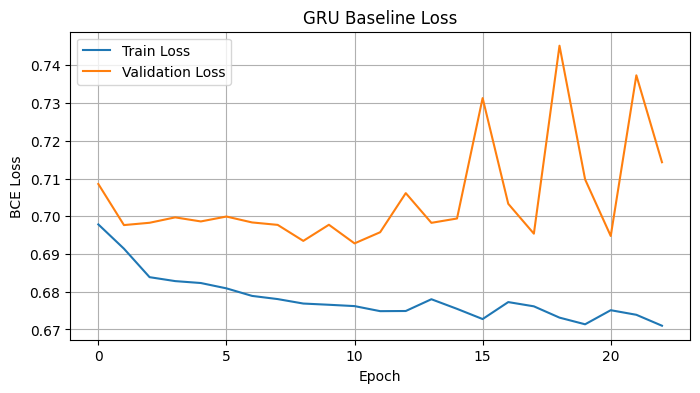

In [ ]:
dropout = 0.2


gru_baseline_model = train_gru(
    X_train_scaled,
    y_train_seq,
    X_val_scaled,
    y_val_seq,
    hidden_size=64,
    num_layers=2,
    dropout=dropout,
    learning_rate=0.0005,
    batch_size=32,
    num_epochs=100,
    patience=12,
    random_state=42,
    verbose=True
)

plot_gru_losses(gru_baseline_model, "GRU Baseline Loss")

In [17]:
val_prob = predict_gru_proba(gru_baseline_model, X_val_scaled)

gru_val_preds = make_gru_prediction_output(
    val_meta,
    val_prob,
    "gru",
    "baseline",
    "val"
)

gru_val_preds.head()

,Date,Price,returns,vol_20,Target,prob_up,pred,model,version,split
0,2022-01-17,83.69,-0.001671,0.014459,1,0.679426,1,gru,baseline,val
1,2022-01-18,84.83,0.013530,0.013529,1,0.679620,1,gru,baseline,val
2,2022-01-19,85.80,0.011370,0.013238,0,0.678972,1,gru,baseline,val
3,2022-01-20,85.55,-0.002918,0.013390,0,0.677668,1,gru,baseline,val
4,2022-01-21,84.14,-0.016619,0.013859,0,0.675424,1,gru,baseline,val


## 9. Generate Baseline GRU Predictions

The baseline GRU predictions are generated for the train, validation, and test periods. The output format matches the other model notebooks and includes predicted up probabilities, hard class predictions, realized targets, realized returns, and metadata needed for trading evaluation.

In [18]:
train_prob = predict_gru_proba(gru_baseline_model, X_train_scaled)
val_prob = predict_gru_proba(gru_baseline_model, X_val_scaled)
test_prob = predict_gru_proba(gru_baseline_model, X_test_scaled)

gru_train_preds = make_gru_prediction_output(
    train_meta, train_prob, "gru", "baseline", "train"
)

gru_val_preds = make_gru_prediction_output(
    val_meta, val_prob, "gru", "baseline", "val"
)

gru_test_preds = make_gru_prediction_output(
    test_meta, test_prob, "gru", "baseline", "test"
)

In [ ]:
os.makedirs("results/predictions", exist_ok=True)

gru_train_preds.to_csv("results/predictions/gru_baseline_train_predictions.csv", index=False)
gru_val_preds.to_csv("results/predictions/gru_baseline_val_predictions.csv", index=False)
gru_test_preds.to_csv("results/predictions/gru_baseline_test_predictions.csv", index=False)

The summary below checks the distribution of validation-set predicted probabilities. This is useful for detecting whether the GRU is producing meaningful probability variation or collapsing near a constant value.

In [20]:
gru_val_preds[["prob_up", "pred", "Target", "returns", "vol_20"]].describe()

,prob_up,pred,Target,returns,vol_20
count,518.000000,518.000000,518.000000,518.000000,518.000000
mean,0.554183,0.760618,0.528958,-0.000298,0.024290
std,0.066808,0.427119,0.499643,0.025769,0.008701
min,0.417828,0.000000,0.000000,-0.134360,0.008609
25%,0.502650,1.000000,0.000000,-0.015524,0.019349
50%,0.553825,1.000000,1.000000,0.001631,0.022910
75%,0.600595,1.000000,1.000000,0.016634,0.027457
max,0.714814,1.000000,1.000000,0.082612,0.055159


The histogram below shows the distribution of predicted upward-move probabilities on the validation set.

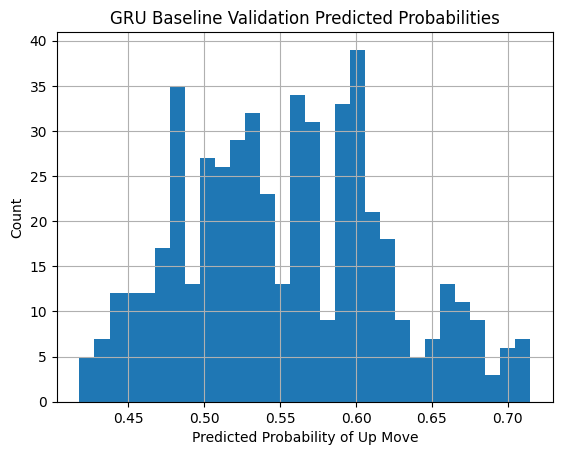

In [21]:
plt.hist(gru_val_preds["prob_up"], bins=30)
plt.title("GRU Baseline Validation Predicted Probabilities")
plt.xlabel("Predicted Probability of Up Move")
plt.ylabel("Count")
plt.grid(True)
plt.show()

## 10. Baseline Classification Evaluation

The classification metrics evaluate directional forecasting performance. Accuracy measures the overall fraction of correct up/down predictions, precision measures how often predicted up moves were correct, recall measures how many actual up moves were captured, F1 balances precision and recall, and ROC-AUC evaluates the ranking quality of predicted probabilities.

In [ ]:
def classification_report_simple(preds):
    y_true = preds["Target"]
    y_pred = preds["pred"]
    prob = preds["prob_up"]

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, prob),
        "confusion_matrix": confusion_matrix(y_true, y_pred)
    }


In [24]:
classification_report_simple(gru_val_preds)

{'accuracy': 0.5405405405405406,
 'precision': 0.5456852791878173,
 'recall': 0.7846715328467153,
 'f1': 0.6437125748502994,
 'roc_auc': 0.5355839416058394,
 'confusion_matrix': array([[ 65, 179],
        [ 59, 215]], dtype=int64)}

In [25]:
classification_report_simple(gru_test_preds)

{'accuracy': 0.49137931034482757,
 'precision': 0.48514851485148514,
 'recall': 0.21030042918454936,
 'f1': 0.2934131736526946,
 'roc_auc': 0.48282332831689057,
 'confusion_matrix': array([[179,  52],
        [184,  49]], dtype=int64)}

## 10. Baseline Classification Evaluation

The classification metrics evaluate directional forecasting performance. Accuracy measures the overall fraction of correct up/down predictions, precision measures how often predicted up moves were correct, recall measures how many actual up moves were captured, F1 balances precision and recall, and ROC-AUC evaluates the ranking quality of predicted probabilities.

In [26]:
def apply_probability_vol_strategy(
    preds,
    target_annual_vol=0.15,
    vol_col="vol_20",
    transaction_cost=0.0005,
    vol_floor=0.005,
    alpha=1.0,
    beta=1.0,
    gamma=1.0
):
    df = preds.copy()

    raw_signal = 2.5 * df["prob_up"] - 1

    raw_signal = np.where(
        raw_signal >= 0,
        alpha * raw_signal,
        beta * raw_signal
    )

    raw_signal = np.sign(raw_signal) * (np.abs(raw_signal) ** gamma)

    target_daily_vol = target_annual_vol / np.sqrt(252)
    adjusted_vol = df[vol_col].clip(lower=vol_floor)

    df["position"] = raw_signal * (target_daily_vol / adjusted_vol)
    df["position"] = df["position"].clip(-1, 1)

    df["turnover"] = (df["position"] - df["position"].shift(1)).abs()

    df["gross_strategy_return"] = df["position"].shift(1) * df["returns"]
    df["net_strategy_return"] = df["gross_strategy_return"] - transaction_cost * df["turnover"]

    df["buy_hold_return"] = df["returns"]

    return df

gru_val_strategy = apply_probability_vol_strategy(gru_val_preds)

## 12. Baseline Strategy Evaluation

The strategy metrics compare the GRU-driven validation strategy against a buy-and-hold benchmark. Total return and CAGR measure growth, annualized volatility measures risk, Sharpe ratio measures risk-adjusted performance, and maximum drawdown captures downside risk.

In [173]:
def max_drawdown(cum_returns):
    running_max = cum_returns.cummax()
    drawdown = cum_returns / running_max - 1
    return drawdown.min()

def strategy_metrics(df, return_col):
    data = df.dropna(subset=[return_col]).copy()
    ret = data[return_col]

    cumulative = (1 + ret).cumprod()
    total_return = cumulative.iloc[-1] - 1
    cagr = cumulative.iloc[-1] ** (252 / len(ret)) - 1
    ann_vol = ret.std() * np.sqrt(252)
    sharpe = cagr / ann_vol if ann_vol != 0 else np.nan
    mdd = max_drawdown(cumulative)
    if return_col == "buy_hold_return":
        avg_position = 1.0
        avg_abs_position = 1.0
        avg_turnover = 0.0
    else:
        avg_position = df["position"].mean()
        avg_abs_position = df["position"].abs().mean()
        avg_turnover = df["turnover"].mean()

    return {
        "Total Return": total_return,
        "CAGR": cagr,
        "Annual Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": mdd,
        "Avg Position": avg_position,
        "Avg Abs Position": avg_abs_position,
        "Avg Turnover": avg_turnover,
    }

metrics = pd.DataFrame({
    "GRU Strategy Val": strategy_metrics(gru_val_strategy, "net_strategy_return"),
    "Buy & Hold Val": strategy_metrics(gru_val_strategy, "buy_hold_return")
}).T

metrics 

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
GRU Strategy Val,0.011163,0.005426,0.071044,0.076369,-0.116825,0.163978,0.163978,0.00911
Buy & Hold Val,-0.279903,-0.147641,0.409072,-0.360916,-0.509424,1.000000,1.000000,0.00000


The cumulative-growth plot compares validation-period performance of the baseline GRU strategy against buy-and-hold.

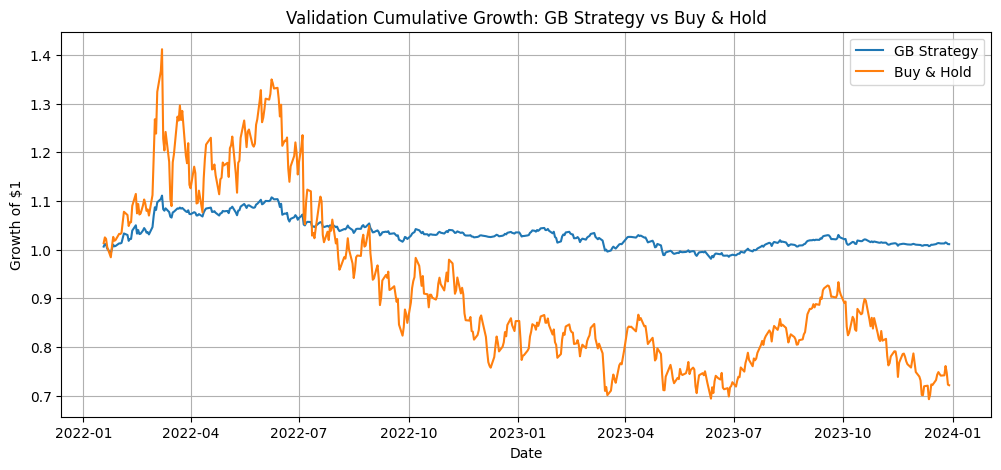

In [ ]:
plot_df = gru_val_strategy.dropna(subset=["net_strategy_return"]).copy()

plot_df["cum_strategy"] = (1 + plot_df["net_strategy_return"]).cumprod()
plot_df["cum_buy_hold"] = (1 + plot_df["buy_hold_return"]).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(plot_df["Date"], plot_df["cum_strategy"], label="GB Strategy")
plt.plot(plot_df["Date"], plot_df["cum_buy_hold"], label="Buy & Hold")
plt.legend()
plt.title("Validation Cumulative Growth: GB Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

## 13. Probability Calibration Check

To understand whether higher GRU predicted probabilities correspond to stronger realized outcomes, I group validation predictions into probability buckets and compare average predicted probability, realized upward-move frequency, and average return.

In [211]:
val_bucket = gru_val_preds.copy()

val_bucket["bucket"] = pd.cut(val_bucket["prob_up"], bins=10)

bucket_stats = val_bucket.groupby("bucket", observed=False).agg({
    "returns": "mean",
    "Target": "mean",
    "prob_up": "mean"
})

bucket_stats

,returns,Target,prob_up
bucket,,,
"(0.418, 0.448]",-0.008816,0.333333,0.436898
"(0.448, 0.477]",0.000234,0.487805,0.464030
"(0.477, 0.507]",-0.000065,0.546667,0.490831
"(0.507, 0.537]",0.001842,0.540230,0.522600
"(0.537, 0.566]",-0.002045,0.528571,0.552927
"(0.566, 0.596]",0.000664,0.534247,0.581264
"(0.596, 0.626]",-0.002773,0.538462,0.607939
"(0.626, 0.655]",0.012219,0.571429,0.639754
"(0.655, 0.685]",-0.002986,0.545455,0.668269


# Regime-Feature GRU Model

This section trains a GRU using the HMM regime probabilities as additional predictors. Unlike the baseline GRU, this version allows the sequence model to condition its predictions on latent market-regime information estimated from macroeconomic, market-state, and CFTC/COT positioning variables.

## 14. Reload Baseline Splits for Alignment

The baseline train, validation, and test splits are reloaded to ensure the HMM-augmented files are aligned to the same dates used by the supervised GRU models.

In [61]:
train_df = pd.read_csv("train_final.csv")
val_df = pd.read_csv("val_final.csv")
test_df = pd.read_csv("test_final.csv")

for df in [train_df, val_df, test_df]:
    df["returns"] = np.log(df["Price"]).diff()
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)

for df in [train_df, val_df, test_df]:
    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)
    df.reset_index(drop=True, inplace=True)

print(train_df.shape, val_df.shape, test_df.shape)
print(train_df["Date"].min(), train_df["Date"].max())
print(val_df["Date"].min(), val_df["Date"].max())
print(test_df["Date"].min(), test_df["Date"].max())

(1742, 50) (528, 50) (474, 50)
2015-05-24 00:00:00 2021-12-31 00:00:00
2022-01-04 00:00:00 2023-12-29 00:00:00
2024-01-03 00:00:00 2025-10-31 00:00:00


## 15. Load HMM-Augmented Modeling Files

The HMM notebook exports train, validation, and test files containing the original predictors plus the regime label and regime probability features. I load those files here and align them with the baseline split dates before training the regime-feature GRU.

In [62]:
train_df_2 = pd.read_csv("train_final_weighted_hmm.csv")
val_df_2 = pd.read_csv("val_final_weighted_hmm.csv")
test_df_2 = pd.read_csv("test_final_weighted_hmm.csv")

for df in [train_df_2, val_df_2, test_df_2]:
    if "macro_month" in df.columns:
        df.drop(columns=["macro_month"], inplace=True)

    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)
    df.reset_index(drop=True, inplace=True)

print(train_df_2.shape, val_df_2.shape, test_df_2.shape)
print(train_df_2["Date"].min(), train_df_2["Date"].max())
print(val_df_2["Date"].min(), val_df_2["Date"].max())
print(test_df_2["Date"].min(), test_df_2["Date"].max())

(1744, 50) (529, 50) (475, 50)
2015-05-21 00:00:00 2021-12-31 00:00:00
2022-01-03 00:00:00 2023-12-29 00:00:00
2024-01-02 00:00:00 2025-10-31 00:00:00


In [63]:
train_df_2 = train_df_2[train_df_2["Date"].isin(train_df["Date"])].copy()
val_df_2 = val_df_2[val_df_2["Date"].isin(val_df["Date"])].copy()
test_df_2 = test_df_2[test_df_2["Date"].isin(test_df["Date"])].copy()

def align_returns_to_base(df_regime, df_base):
    df_regime = df_regime.drop(columns=["returns"], errors="ignore")

    out = df_regime.merge(
        df_base[["Date", "returns"]],
        on="Date",
        how="left"
    )

    return out.sort_values("Date").reset_index(drop=True)

train_df_2 = align_returns_to_base(train_df_2, train_df)
val_df_2 = align_returns_to_base(val_df_2, val_df)
test_df_2 = align_returns_to_base(test_df_2, test_df)

print(train_df_2.shape, val_df_2.shape, test_df_2.shape)

(1742, 50) (528, 50) (474, 50)


## 16. Define Regime-Feature GRU Inputs

This feature set includes two HMM regime probability columns and excludes the hard regime label. One regime probability is dropped because the three probabilities sum to one, so including all three would introduce perfect redundancy.

In [64]:
target_col = "Target"

regime_feature_exclude_cols = [
    "Date",
    "Price",
    "returns",
    "Target",
    "regime"
]

feature_cols_2 = [c for c in train_df_2.columns if c not in regime_feature_exclude_cols]

print("Feature count:", len(feature_cols_2))
print("Added features:", set(feature_cols_2) - set(feature_cols))

Feature count: 45
Added features: {'regime_prob_2', 'regime_prob_1', 'regime_prob_0'}


In [65]:
lookback = 10

X_train_seq_2, y_train_seq_2, train_meta_2 = make_sequences(
    train_df_2, feature_cols_2, target_col, lookback
)

X_val_seq_2, y_val_seq_2, val_meta_2 = make_sequences(
    val_df_2, feature_cols_2, target_col, lookback
)

X_test_seq_2, y_test_seq_2, test_meta_2 = make_sequences(
    test_df_2, feature_cols_2, target_col, lookback
)

print("Train:", X_train_seq_2.shape, y_train_seq_2.shape, train_meta_2.shape)
print("Val:", X_val_seq_2.shape, y_val_seq_2.shape, val_meta_2.shape)
print("Test:", X_test_seq_2.shape, y_test_seq_2.shape, test_meta_2.shape)

Train: (1732, 10, 45) (1732,) (1732, 5)
Val: (518, 10, 45) (518,) (518, 5)
Test: (464, 10, 45) (464,) (464, 5)


## 17. Tune the Regime-Feature GRU

This tuning step repeats the same time-series cross-validation process after adding HMM regime probabilities. The goal is to evaluate whether regime information improves validation performance relative to the baseline feature set.

In [99]:
tscv = TimeSeriesSplit(n_splits=5)

param_list_2 = list(ParameterGrid(param_grid))
print("Total parameter combinations:", len(param_list_2))

cv_results_2 = []

for combo_num, params in enumerate(param_list_2, start=1):
    print(f"\nRunning combo {combo_num}/{len(param_list_2)}")
    print(params)

    fold_aucs = []
    fold_accs = []
    fold_best_val_losses = []
    fold_final_train_losses = []

    for fold, (train_idx, cv_idx) in enumerate(tscv.split(X_train_seq_2), start=1):
        X_fold_train = X_train_seq_2[train_idx]
        y_fold_train = y_train_seq_2[train_idx]

        X_fold_val = X_train_seq_2[cv_idx]
        y_fold_val = y_train_seq_2[cv_idx]

        X_fold_train_scaled, X_fold_val_scaled, _ = fit_transform_sequence_scaler(
            X_fold_train,
            X_fold_val
        )

        dropout = 0.2 if params["num_layers"] > 1 else 0.0

        model = train_gru(
            X_train=X_fold_train_scaled,
            y_train=y_fold_train,
            X_val=X_fold_val_scaled,
            y_val=y_fold_val,
            hidden_size=params["hidden_size"],
            num_layers=params["num_layers"],
            dropout=dropout,
            learning_rate=params["learning_rate"],
            batch_size=params["batch_size"],
            num_epochs=50,
            patience=7,
            random_state=42,
            verbose=False
        )

        y_fold_prob = predict_gru_proba(model, X_fold_val_scaled)
        y_fold_pred = (y_fold_prob >= 0.5).astype(int)

        acc = accuracy_score(y_fold_val, y_fold_pred)

        try:
            auc = roc_auc_score(y_fold_val, y_fold_prob)
        except ValueError:
            auc = np.nan

        best_val_loss = np.min(model.val_losses) if len(model.val_losses) > 0 else np.nan
        final_train_loss = model.train_losses[-1] if len(model.train_losses) > 0 else np.nan

        fold_accs.append(acc)
        fold_aucs.append(auc)
        fold_best_val_losses.append(best_val_loss)
        fold_final_train_losses.append(final_train_loss)

        print(
            f"  Fold {fold}: "
            f"AUC={auc:.4f}, ACC={acc:.4f}, "
            f"Best Val Loss={best_val_loss:.4f}"
        )

    result = {
        **params,
        "mean_cv_auc": np.nanmean(fold_aucs),
        "std_cv_auc": np.nanstd(fold_aucs),
        "mean_cv_accuracy": np.mean(fold_accs),
        "std_cv_accuracy": np.std(fold_accs),
        "mean_best_val_loss": np.nanmean(fold_best_val_losses),
        "mean_final_train_loss": np.nanmean(fold_final_train_losses)
    }

    cv_results_2.append(result)

cv_results_df_2 = pd.DataFrame(cv_results_2).sort_values(
    by="mean_cv_auc",
    ascending=False
).reset_index(drop=True)

cv_results_df_2.head(10)

Total parameter combinations: 72

Running combo 1/72
{'batch_size': 16, 'hidden_size': 16, 'learning_rate': 0.001, 'num_layers': 1}
  Fold 1: AUC=0.5132, ACC=0.5278, Best Val Loss=0.6914
  Fold 2: AUC=0.4803, ACC=0.5972, Best Val Loss=0.6798
  Fold 3: AUC=0.5420, ACC=0.5278, Best Val Loss=0.6941
  Fold 4: AUC=0.5528, ACC=0.5104, Best Val Loss=0.6923
  Fold 5: AUC=0.4987, ACC=0.6007, Best Val Loss=0.6794

Running combo 2/72
{'batch_size': 16, 'hidden_size': 16, 'learning_rate': 0.001, 'num_layers': 2}
  Fold 1: AUC=0.5687, ACC=0.5451, Best Val Loss=0.6854
  Fold 2: AUC=0.5110, ACC=0.5972, Best Val Loss=0.6741
  Fold 3: AUC=0.4927, ACC=0.5174, Best Val Loss=0.7022
  Fold 4: AUC=0.4764, ACC=0.4965, Best Val Loss=0.6978
  Fold 5: AUC=0.4622, ACC=0.5938, Best Val Loss=0.6783

Running combo 3/72
{'batch_size': 16, 'hidden_size': 16, 'learning_rate': 0.0005, 'num_layers': 1}
  Fold 1: AUC=0.5115, ACC=0.5208, Best Val Loss=0.6920
  Fold 2: AUC=0.4720, ACC=0.5903, Best Val Loss=0.6819
  Fold 3:

,batch_size,hidden_size,learning_rate,num_layers,mean_cv_auc,std_cv_auc,mean_cv_accuracy,std_cv_accuracy,mean_best_val_loss,mean_final_train_loss
0,64,64,0.0005,1,0.553018,0.017290,0.559028,0.035478,0.687285,0.667728
1,64,64,0.0010,1,0.551479,0.015681,0.554861,0.040813,0.690615,0.659305
2,32,64,0.0005,1,0.543039,0.020695,0.552778,0.041166,0.689557,0.660818
3,64,64,0.0010,2,0.540869,0.029220,0.556250,0.038440,0.692493,0.666752
4,32,64,0.0010,1,0.537817,0.034839,0.550000,0.044876,0.692416,0.653835
5,16,64,0.0010,2,0.537196,0.023877,0.560417,0.031103,0.693381,0.668476
6,64,128,0.0010,2,0.535668,0.030616,0.554861,0.029901,0.693819,0.671353
7,32,64,0.0001,1,0.534711,0.021326,0.556250,0.032970,0.685410,0.677004
8,64,64,0.0001,1,0.532989,0.019981,0.556250,0.037998,0.685092,0.679654
9,16,64,0.0010,1,0.532386,0.032118,0.552778,0.038314,0.696452,0.646103


In [101]:
best_params_2 = cv_results_df_2.iloc[0].to_dict()
best_params_2

{'batch_size': 64.0,
 'hidden_size': 64.0,
 'learning_rate': 0.0005,
 'num_layers': 1.0,
 'mean_cv_auc': 0.5530182345620366,
 'std_cv_auc': 0.017289619573393696,
 'mean_cv_accuracy': 0.5590277777777779,
 'std_cv_accuracy': 0.035477888262346643,
 'mean_best_val_loss': 0.6872852087020874,
 'mean_final_train_loss': 0.6677277416161624}

## 18. Fit the Regime-Feature GRU

Using the selected hyperparameters, I fit the regime-feature GRU on the training sequences and monitor validation loss.

Epoch 1/100 | Train Loss: 0.7025 | Val Loss: 0.6966
Epoch 2/100 | Train Loss: 0.6903 | Val Loss: 0.6915
Epoch 3/100 | Train Loss: 0.6857 | Val Loss: 0.6927
Epoch 4/100 | Train Loss: 0.6832 | Val Loss: 0.6927
Epoch 5/100 | Train Loss: 0.6815 | Val Loss: 0.6926
Epoch 6/100 | Train Loss: 0.6801 | Val Loss: 0.6923
Epoch 7/100 | Train Loss: 0.6789 | Val Loss: 0.6921
Epoch 8/100 | Train Loss: 0.6778 | Val Loss: 0.6919
Epoch 9/100 | Train Loss: 0.6768 | Val Loss: 0.6917
Epoch 10/100 | Train Loss: 0.6759 | Val Loss: 0.6916
Epoch 11/100 | Train Loss: 0.6749 | Val Loss: 0.6914
Epoch 12/100 | Train Loss: 0.6739 | Val Loss: 0.6912
Epoch 13/100 | Train Loss: 0.6729 | Val Loss: 0.6911
Epoch 14/100 | Train Loss: 0.6718 | Val Loss: 0.6912
Epoch 15/100 | Train Loss: 0.6707 | Val Loss: 0.6913
Epoch 16/100 | Train Loss: 0.6695 | Val Loss: 0.6915
Epoch 17/100 | Train Loss: 0.6682 | Val Loss: 0.6919
Epoch 18/100 | Train Loss: 0.6669 | Val Loss: 0.6924
Epoch 19/100 | Train Loss: 0.6654 | Val Loss: 0.6928
Ep

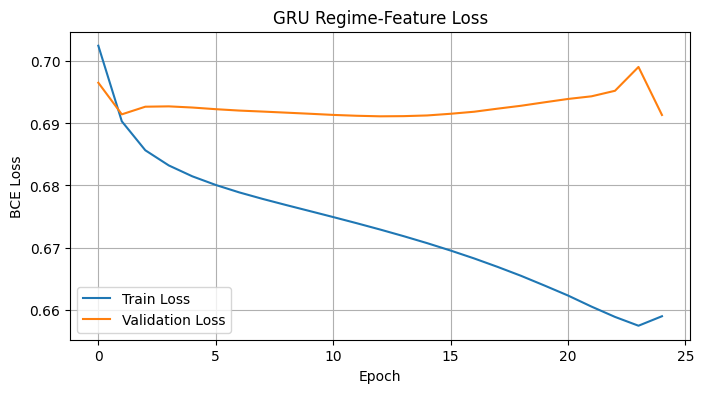

In [ ]:
X_train_scaled_2, X_val_scaled_2, seq_scaler_2 = fit_transform_sequence_scaler(
    X_train_seq_2,
    X_val_seq_2
)

_, X_test_scaled_2, _ = fit_transform_sequence_scaler(
    X_train_seq_2,
    X_test_seq_2
)

gru_regime_feature_model = train_gru(
    X_train=X_train_scaled_2,
    y_train=y_train_seq_2,
    X_val=X_val_scaled_2,
    y_val=y_val_seq_2,
    hidden_size=64,
    num_layers=1,
    dropout=0.2,
    learning_rate=0.0005,
    batch_size=64,
    num_epochs=100,
    patience=12,
    random_state=42,
    verbose=True
)

plot_gru_losses(gru_regime_feature_model, "GRU Regime-Feature Loss")

## 19. Generate Regime-Feature GRU Predictions

The regime-feature GRU predictions are generated in the same format as the baseline model, allowing classification and trading performance to be compared directly across model versions.

In [66]:
train_prob_2 = predict_gru_proba(gru_regime_feature_model, X_train_scaled_2)
val_prob_2 = predict_gru_proba(gru_regime_feature_model, X_val_scaled_2)
test_prob_2 = predict_gru_proba(gru_regime_feature_model, X_test_scaled_2)

gru_train_preds_2 = make_gru_prediction_output(
    train_meta_2, train_prob_2, "gru", "regime_feature", "train"
)

gru_val_preds_2 = make_gru_prediction_output(
    val_meta_2, val_prob_2, "gru", "regime_feature", "val"
)

gru_test_preds_2 = make_gru_prediction_output(
    test_meta_2, test_prob_2, "gru", "regime_feature", "test"
)

In [38]:
gru_train_preds_2.to_csv("results/predictions/gru_regime_feature_train_predictions.csv", index=False)
gru_val_preds_2.to_csv("results/predictions/gru_regime_feature_val_predictions.csv", index=False)
gru_test_preds_2.to_csv("results/predictions/gru_regime_feature_test_predictions.csv", index=False)

In [67]:
gru_val_preds_2[["prob_up", "pred", "Target", "returns", "vol_20"]].describe()

,prob_up,pred,Target,returns,vol_20
count,518.000000,518.000000,518.000000,518.000000,518.000000
mean,0.551755,0.866795,0.528958,-0.000298,0.024290
std,0.057717,0.340124,0.499643,0.025769,0.008701
min,0.425755,0.000000,0.000000,-0.134360,0.008609
25%,0.514953,1.000000,0.000000,-0.015524,0.019349
50%,0.537774,1.000000,1.000000,0.001631,0.022910
75%,0.588222,1.000000,1.000000,0.016634,0.027457
max,0.701410,1.000000,1.000000,0.082612,0.055159


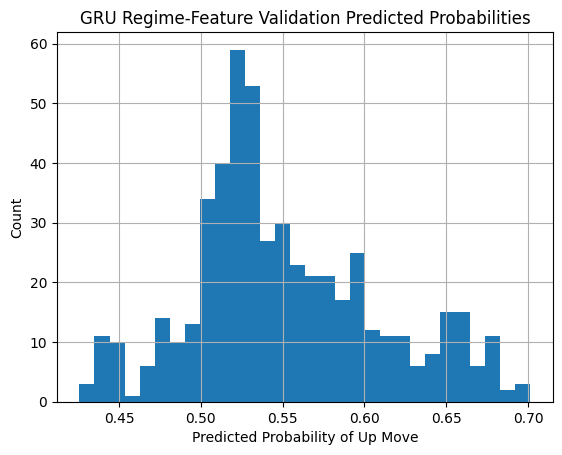

In [68]:
plt.hist(gru_val_preds_2["prob_up"], bins=30)
plt.title("GRU Regime-Feature Validation Predicted Probabilities")
plt.xlabel("Predicted Probability of Up Move")
plt.ylabel("Count")
plt.grid(True)
plt.show()

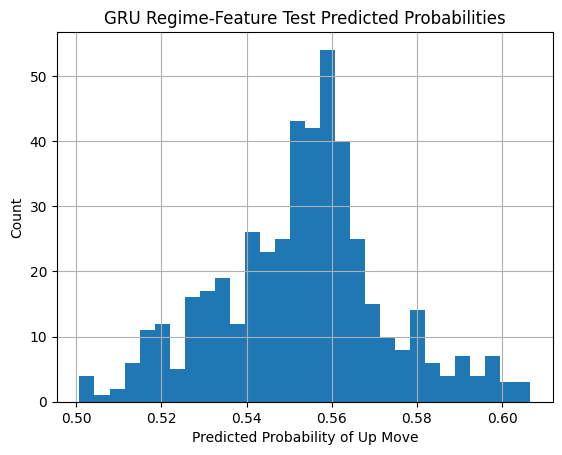

In [69]:
plt.hist(gru_test_preds_2["prob_up"], bins=30)
plt.title("GRU Regime-Feature Test Predicted Probabilities")
plt.xlabel("Predicted Probability of Up Move")
plt.ylabel("Count")
plt.grid(True)
plt.show()

In [42]:
classification_report_simple(gru_val_preds_2)

{'accuracy': 0.5347490347490348,
 'precision': 0.5367483296213809,
 'recall': 0.8795620437956204,
 'f1': 0.6666666666666666,
 'roc_auc': 0.5415669498623907,
 'confusion_matrix': array([[ 36, 208],
        [ 33, 241]], dtype=int64)}

In [43]:
classification_report_simple(gru_test_preds_2)

{'accuracy': 0.5021551724137931,
 'precision': 0.5021551724137931,
 'recall': 1.0,
 'f1': 0.6685796269727403,
 'roc_auc': 0.5093918956579901,
 'confusion_matrix': array([[  0, 231],
        [  0, 233]], dtype=int64)}

In [174]:
gru_val_strategy_2 = apply_probability_vol_strategy(gru_val_preds_2)

gru_metrics_2 = pd.DataFrame({
    "GRU Regime-Feature Strategy Val": strategy_metrics(gru_val_strategy_2, "net_strategy_return"),
    "Buy & Hold Val": strategy_metrics(gru_val_strategy_2, "buy_hold_return")
}).T

gru_metrics_2

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
GRU Regime-Feature Strategy Val,0.017646,0.008562,0.067732,0.126415,-0.105835,0.162841,0.162841,0.009016
Buy & Hold Val,-0.279903,-0.147641,0.409072,-0.360916,-0.509424,1.000000,1.000000,0.000000


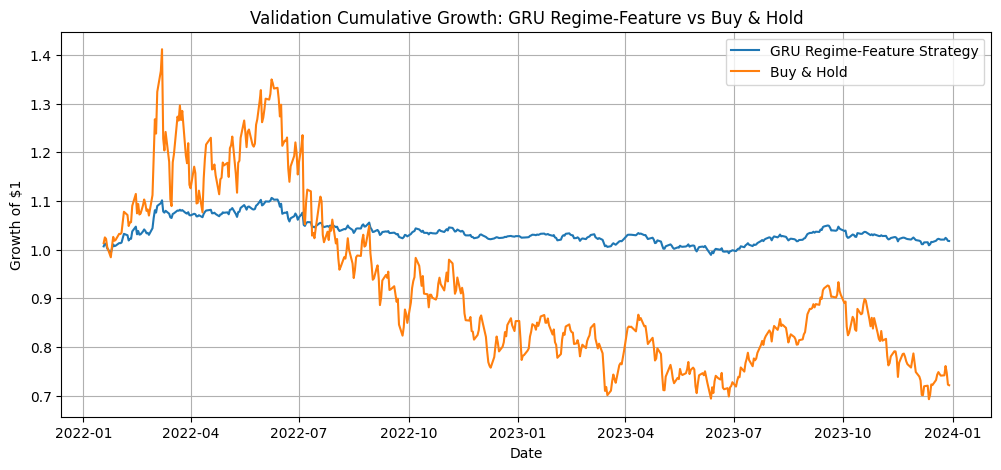

In [45]:
plot_df_2 = gru_val_strategy_2.dropna(subset=["net_strategy_return"]).copy()

plot_df_2["cum_strategy"] = (1 + plot_df_2["net_strategy_return"]).cumprod()
plot_df_2["cum_buy_hold"] = (1 + plot_df_2["buy_hold_return"]).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(plot_df_2["Date"], plot_df_2["cum_strategy"], label="GRU Regime-Feature Strategy")
plt.plot(plot_df_2["Date"], plot_df_2["cum_buy_hold"], label="Buy & Hold")
plt.legend()
plt.title("Validation Cumulative Growth: GRU Regime-Feature vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

The bucket analysis checks whether the regime-feature GRU's predicted probabilities are directionally meaningful across probability ranges.

In [46]:
gru_val_bucket_2 = gru_val_preds_2.copy()

gru_val_bucket_2["bucket"] = pd.cut(gru_val_bucket_2["prob_up"], bins=10)

gru_bucket_stats_2 = gru_val_bucket_2.groupby("bucket", observed=False).agg({
    "returns": "mean",
    "Target": "mean",
    "prob_up": "mean"
})

gru_bucket_stats_2

,returns,Target,prob_up
bucket,,,
"(0.425, 0.453]",-0.001677,0.541667,0.443281
"(0.453, 0.481]",-0.000610,0.380952,0.473126
"(0.481, 0.508]",-0.007093,0.421053,0.498955
"(0.508, 0.536]",0.000741,0.552632,0.523018
"(0.536, 0.564]",0.002575,0.525000,0.549411
"(0.564, 0.591]",-0.000289,0.525424,0.576890
"(0.591, 0.619]",-0.004866,0.520833,0.602310
"(0.619, 0.646]",0.006206,0.640000,0.631950
"(0.646, 0.674]",0.002273,0.611111,0.657593


# Regime-Specific GRU Model

This section trains separate GRU classifiers by lagged HMM regime. Instead of using one global sequence model for all market environments, the regime-specific approach allows the temporal relationship between predictors and WTI direction to differ across regimes.

For the GRU, the sequence is still built from consecutive daily observations. The target date's lagged regime is then used to decide which regime-specific model should train on or predict that observation.

## 20. Construct Lagged Regime Labels

The regime-specific GRU uses the previous day's regime label. This prevents the model from using same-day regime information that would not have been available before the current day's return was realized.

In [73]:
train_df_3 = train_df_2.copy()
val_df_3 = val_df_2.copy()
test_df_3 = test_df_2.copy()

for df in [train_df_3, val_df_3, test_df_3]:
    df["regime_lag"] = df["regime"].shift(1)

train_df_3 = train_df_3.dropna(subset=["regime_lag"]).copy()
val_df_3 = val_df_3.dropna(subset=["regime_lag"]).copy()
test_df_3 = test_df_3.dropna(subset=["regime_lag"]).copy()

print(train_df_3["regime_lag"].value_counts())
print(val_df_3["regime_lag"].value_counts())
print(test_df_3["regime_lag"].value_counts())

regime_lag
1.0    693
0.0    662
2.0    386
Name: count, dtype: int64
regime_lag
0.0    324
1.0    161
2.0     42
Name: count, dtype: int64
regime_lag
0.0    349
1.0    124
Name: count, dtype: int64


## 21. Define Regime-Specific GRU Feature Set

For the regime-specific GRU, the hard regime label and lagged regime label are not used as predictors. They are used only to split target dates into regime-specific models. The HMM regime probabilities are also excluded because this version trains separate models by regime instead of giving regime probabilities to one global model.

In [76]:
regime_specific_exclude_cols = [
    "Date",
    "Price",
    "returns",
    "Target",
    "regime",
    "regime_lag",
    "regime_prob_0",
    "regime_prob_1",
    "regime_prob_2"
]

feature_cols_3 = [c for c in train_df_3.columns if c not in regime_specific_exclude_cols]

print("Feature count:", len(feature_cols_3))
print(feature_cols_3)

Feature count: 42
['RPI', 'W875RX1', 'CMRMTSPLx', 'IPFPNSS', 'USWTRADE', 'USTRADE', 'BUSLOANS', 'CONSPI', 'S&P 500', 'S&P PE ratio', 'FEDFUNDS', 'TB3MS', 'TB6MS', 'GS1', 'GS5', 'GS10', 'AAA', 'BAA', 'TB3SMFFM', 'TB6SMFFM', 'T1YFFM', 'T5YFFM', 'T10YFFM', 'AAAFFM', 'BAAFFM', 'EXSZUSx', 'EXJPUSx', 'EXUSUKx', 'EXCAUSx', 'PPICMM', 'UMCSENTx', 'net_position', 'net_position_pct', 'flow', 'long_short_ratio', 'Open_Interest_All', 'oi_change', 'vol_20', 'momentum_20', 'vol_60', 'drawdown', 'trend']


## 22. Build Regime-Specific GRU Sequences

For the regime-specific GRU, I first build normal consecutive daily sequences, then assign each sequence to a regime based on the target date's lagged regime. This is preferable to filtering the dataframe by regime before sequence construction because filtering first can create artificial sequences across non-consecutive dates.

In [78]:
def make_sequences_for_regime(df, feature_cols, target_col="Target", lookback=10):
    df = df.sort_values("Date").reset_index(drop=True)

    X = []
    y = []
    meta_rows = []

    values = df[feature_cols].values.astype(np.float32)
    targets = df[target_col].values.astype(np.float32)

    for i in range(lookback, len(df)):
        X.append(values[i-lookback:i])
        y.append(targets[i])

        meta_rows.append({
            "Date": df["Date"].iloc[i],
            "Price": df["Price"].iloc[i],
            "returns": df["returns"].iloc[i],
            "vol_20": df["vol_20"].iloc[i],
            "Target": df[target_col].iloc[i],
            "regime_lag": df["regime_lag"].iloc[i]
        })

    return np.array(X), np.array(y), pd.DataFrame(meta_rows)

In [213]:
regime_models_3 = {}
regime_scalers_3 = {}
regime_train_meta_3 = {}
regime_train_preds_list_3 = []

# dropout_3 = 0.2 if int(best_params_2["num_layers"]) > 1 else 0.0


for regime in sorted(train_df_3["regime_lag"].unique()):
    print(f"\n==============================")
    print(f"Training regime-specific GRU for regime {regime}")
    print(f"==============================")

    train_r = train_df_3[train_df_3["regime_lag"] == regime].copy()

    X_train_r, y_train_r, train_meta_r = make_sequences_for_regime(
        train_r,
        feature_cols_3,
        target_col,
        lookback
    )

    print("Sequences:", X_train_r.shape)

    if len(X_train_r) < 20:
        print(f"Skipping regime {regime}: too few sequences")
        continue

    split_idx = int(len(X_train_r) * 0.8)

    X_r_train = X_train_r[:split_idx]
    y_r_train = y_train_r[:split_idx]

    X_r_val = X_train_r[split_idx:]
    y_r_val = y_train_r[split_idx:]

    X_r_train_scaled, X_r_val_scaled, scaler_r = fit_transform_sequence_scaler(
        X_r_train,
        X_r_val
    )

    model_r = train_gru(
        X_train=X_r_train_scaled,
        y_train=y_r_train,
        X_val=X_r_val_scaled,
        y_val=y_r_val,
        hidden_size=64,
        num_layers=1,
        dropout=0.2,
        learning_rate=0.0005,
        batch_size=64,
        num_epochs=100,
        patience=12,
        random_state=42,
        verbose=True
    )

    regime_models_3[regime] = model_r
    regime_scalers_3[regime] = scaler_r
    regime_train_meta_3[regime] = train_meta_r


Training regime-specific GRU for regime 0.0
Sequences: (652, 10, 42)
Epoch 1/100 | Train Loss: 0.6992 | Val Loss: 0.7199
Epoch 2/100 | Train Loss: 0.6875 | Val Loss: 0.7171
Epoch 3/100 | Train Loss: 0.6849 | Val Loss: 0.7173
Epoch 4/100 | Train Loss: 0.6833 | Val Loss: 0.7199
Epoch 5/100 | Train Loss: 0.6813 | Val Loss: 0.7232
Epoch 6/100 | Train Loss: 0.6796 | Val Loss: 0.7258
Epoch 7/100 | Train Loss: 0.6783 | Val Loss: 0.7275
Epoch 8/100 | Train Loss: 0.6772 | Val Loss: 0.7290
Epoch 9/100 | Train Loss: 0.6762 | Val Loss: 0.7307
Epoch 10/100 | Train Loss: 0.6752 | Val Loss: 0.7326
Epoch 11/100 | Train Loss: 0.6742 | Val Loss: 0.7342
Epoch 12/100 | Train Loss: 0.6731 | Val Loss: 0.7357
Epoch 13/100 | Train Loss: 0.6721 | Val Loss: 0.7372
Epoch 14/100 | Train Loss: 0.6710 | Val Loss: 0.7388
Early stopping triggered.

Training regime-specific GRU for regime 1.0
Sequences: (683, 10, 42)
Epoch 1/100 | Train Loss: 0.6843 | Val Loss: 0.6938
Epoch 2/100 | Train Loss: 0.6769 | Val Loss: 0.69

## 24. Generate Regime-Specific GRU Predictions

This helper applies the appropriate regime-specific GRU to each sequence based on the target date's lagged regime. The output format matches the earlier model versions so classification and strategy metrics can be compared directly.

In [84]:
def make_regime_specific_gru_predictions(
    df,
    feature_cols,
    regime_models,
    regime_scalers,
    lookback=10,
    split_name="unknown"
):
    pred_list = []

    for regime, model in regime_models.items():
        df_r = df[df["regime_lag"] == regime].copy()
        df_r = df_r.sort_values("Date").reset_index(drop=True)

        if len(df_r) <= lookback:
            print(f"Skipping regime {regime} in {split_name}: too few rows")
            continue

        X_r, y_r, meta_r = make_sequences_for_regime(
            df_r,
            feature_cols,
            target_col,
            lookback
        )

        scaler_r = regime_scalers[regime]

        n, t, f = X_r.shape
        X_r_scaled = scaler_r.transform(X_r.reshape(-1, f)).reshape(n, t, f)

        probs_r = predict_gru_proba(model, X_r_scaled)

        preds_r = make_gru_prediction_output(
            meta_r,
            probs_r,
            "gru",
            "regime_specific",
            split_name
        )

        preds_r["regime_lag"] = regime
        pred_list.append(preds_r)

    out = pd.concat(pred_list, ignore_index=True)
    out = out.sort_values("Date").reset_index(drop=True)

    return out

In [ ]:
gru_train_preds_3 = make_regime_specific_gru_predictions(
    train_df_3,
    feature_cols_3,
    regime_models_3,
    regime_scalers_3,
    lookback=lookback,
    split_name="train"
)

gru_val_preds_3 = make_regime_specific_gru_predictions(
    val_df_3,
    feature_cols_3,
    regime_models_3,
    regime_scalers_3,
    lookback=lookback,
    split_name="val"
)

gru_test_preds_3 = make_regime_specific_gru_predictions(
    test_df_3,
    feature_cols_3,
    regime_models_3,
    regime_scalers_3,
    lookback=lookback,
    split_name="test"
)

print(gru_train_preds_3.shape)
print(gru_val_preds_3.shape)
print(gru_test_preds_3.shape)

Skipping regime 2.0 in test: too few rows
(1711, 11)
(497, 11)
(453, 11)


The regime-specific GRU prediction files are saved for later comparison and strategy evaluation.

In [86]:
os.makedirs("results/predictions", exist_ok=True)

gru_train_preds_3.to_csv("results/predictions/gru_regime_specific_train_predictions.csv", index=False)
gru_val_preds_3.to_csv("results/predictions/gru_regime_specific_val_predictions.csv", index=False)
gru_test_preds_3.to_csv("results/predictions/gru_regime_specific_test_predictions.csv", index=False)

The summaries below inspect the distribution of predicted probabilities overall and within each lagged regime.

In [87]:
gru_val_preds_3[["prob_up", "pred", "Target", "returns", "vol_20", "regime_lag"]].describe()

,prob_up,pred,Target,returns,vol_20,regime_lag
count,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000
mean,0.521210,0.639839,0.529175,-0.000323,0.023915,0.432596
std,0.051618,0.480531,0.499651,0.024622,0.008548,0.612359
min,0.381665,0.000000,0.000000,-0.134360,0.008609,0.000000
25%,0.478559,0.000000,0.000000,-0.015054,0.019096,0.000000
50%,0.526254,1.000000,1.000000,0.001622,0.022632,0.000000
75%,0.556830,1.000000,1.000000,0.016020,0.026196,1.000000
max,0.631116,1.000000,1.000000,0.082612,0.055159,2.000000


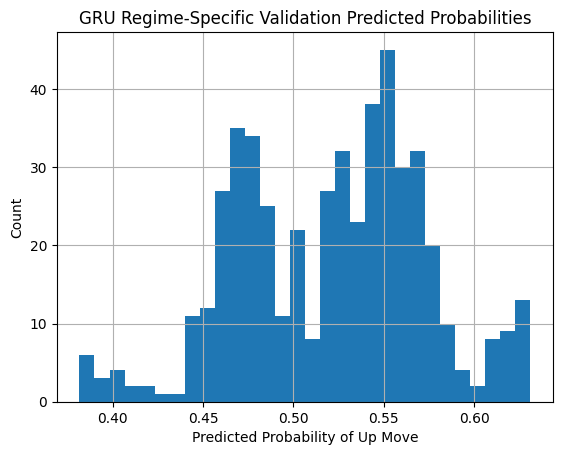

In [88]:
plt.hist(gru_val_preds_3["prob_up"], bins=30)
plt.title("GRU Regime-Specific Validation Predicted Probabilities")
plt.xlabel("Predicted Probability of Up Move")
plt.ylabel("Count")
plt.grid(True)
plt.show()

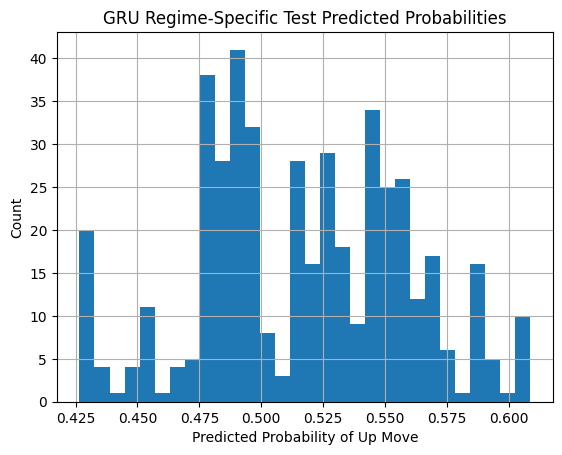

In [89]:
plt.hist(gru_test_preds_3["prob_up"], bins=30)
plt.title("GRU Regime-Specific Test Predicted Probabilities")
plt.xlabel("Predicted Probability of Up Move")
plt.ylabel("Count")
plt.grid(True)
plt.show()

In [90]:
gru_val_preds_3.groupby("regime_lag")["prob_up"].describe()

,count,mean,std,min,25%,50%,75%,max
regime_lag,,,,,,,,
0.0,314.0,0.523497,0.048700,0.443668,0.475672,0.543076,0.560820,0.629861
1.0,151.0,0.499855,0.044371,0.381665,0.486041,0.518998,0.529536,0.554083
2.0,32.0,0.599545,0.023446,0.563848,0.578726,0.608055,0.618739,0.631116


In [91]:
gru_test_preds_3.groupby("regime_lag")["prob_up"].describe()

,count,mean,std,min,25%,50%,75%,max
regime_lag,,,,,,,,
0.0,339.0,0.523829,0.037433,0.469359,0.489822,0.519941,0.551995,0.608711
1.0,114.0,0.496856,0.048665,0.426584,0.449853,0.516934,0.542441,0.567057


The classification reports evaluate the regime-specific GRU on the validation and test periods.

In [92]:
classification_report_simple(gru_val_preds_3)

{'accuracy': 0.5271629778672032,
 'precision': 0.5440251572327044,
 'recall': 0.6577946768060836,
 'f1': 0.5955249569707401,
 'roc_auc': 0.522326216242566,
 'confusion_matrix': array([[ 89, 145],
        [ 90, 173]], dtype=int64)}

In [93]:
classification_report_simple(gru_test_preds_3)

{'accuracy': 0.5187637969094923,
 'precision': 0.5171102661596958,
 'recall': 0.5991189427312775,
 'f1': 0.5551020408163265,
 'roc_auc': 0.522513742154302,
 'confusion_matrix': array([[ 99, 127],
        [ 91, 136]], dtype=int64)}

The regime-specific GRU predictions are converted into trading positions and evaluated using the same strategy rules as the other GRU versions.

In [175]:
gru_val_strategy_3 = apply_probability_vol_strategy(gru_val_preds_3)

gru_metrics_3 = pd.DataFrame({
    "GRU Regime-Specific Strategy Val": strategy_metrics(gru_val_strategy_3, "net_strategy_return"),
    "Buy & Hold Val": strategy_metrics(gru_val_strategy_3, "buy_hold_return")
}).T

gru_metrics_3

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
GRU Regime-Specific Strategy Val,0.023787,0.012015,0.051951,0.231279,-0.052938,0.13661,0.137013,0.008179
Buy & Hold Val,-0.268484,-0.146594,0.390858,-0.375057,-0.497178,1.00000,1.000000,0.000000


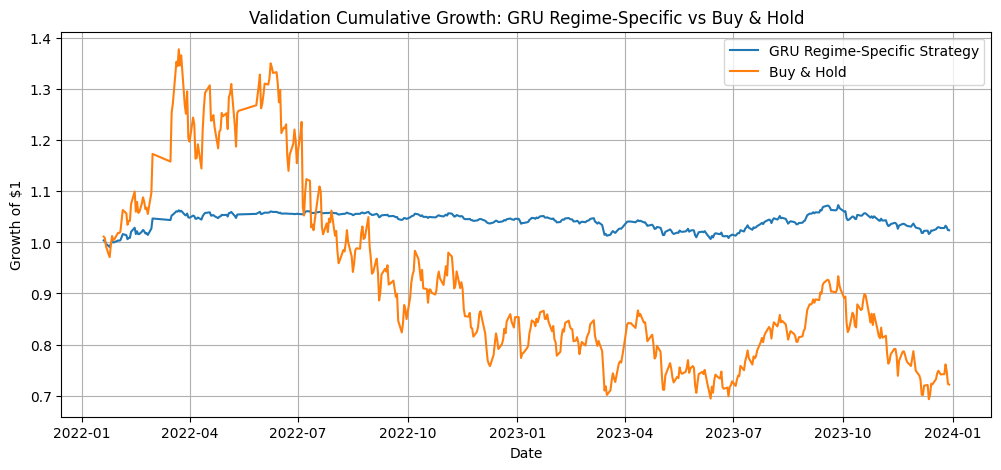

In [95]:
plot_df_3 = gru_val_strategy_3.dropna(subset=["net_strategy_return"]).copy()

plot_df_3["cum_strategy"] = (1 + plot_df_3["net_strategy_return"]).cumprod()
plot_df_3["cum_buy_hold"] = (1 + plot_df_3["buy_hold_return"]).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(plot_df_3["Date"], plot_df_3["cum_strategy"], label="GRU Regime-Specific Strategy")
plt.plot(plot_df_3["Date"], plot_df_3["cum_buy_hold"], label="Buy & Hold")
plt.legend()
plt.title("Validation Cumulative Growth: GRU Regime-Specific vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

In [96]:
gru_val_bucket_3 = gru_val_preds_3.copy()

gru_val_bucket_3["bucket"] = pd.cut(gru_val_bucket_3["prob_up"], bins=10)

gru_bucket_stats_3 = gru_val_bucket_3.groupby("bucket", observed=False).agg({
    "returns": "mean",
    "Target": "mean",
    "prob_up": "mean"
})

gru_bucket_stats_3

,returns,Target,prob_up
bucket,,,
"(0.381, 0.407]",-0.010652,0.461538,0.392550
"(0.407, 0.432]",-0.013190,0.600000,0.419032
"(0.432, 0.457]",-0.001934,0.458333,0.448949
"(0.457, 0.481]",-0.001203,0.500000,0.469622
"(0.481, 0.506]",0.000359,0.534483,0.493161
"(0.506, 0.531]",0.000219,0.582090,0.522211
"(0.531, 0.556]",-0.000942,0.500000,0.545615
"(0.556, 0.581]",0.000625,0.548780,0.567421
"(0.581, 0.606]",0.004779,0.500000,0.589833


# Pre-COT GRU Baseline

This section trains a GRU after removing all CFTC/COT positioning variables. The purpose is to create a clean comparison between the original macro/price-based feature set and the COT-augmented models. This helps isolate whether the alternative COT dataset adds useful predictive or trading information.

## 25. Load and Align the Pre-COT Dataset

The pre-COT baseline uses the original train, validation, and test files before adding the COT-enhanced features. I align the dates to the current modeling splits so comparisons are made on the same sample period. I also align returns to the baseline files so buy-and-hold performance is identical across model versions.

In [ ]:
# GRU PRE-COT BASELINE
# Macro/technical features only, excluding COT features

train_df_pre = pd.read_csv("train_final.csv")
val_df_pre = pd.read_csv("val_final.csv")
test_df_pre = pd.read_csv("test_final.csv")

for df in [train_df_pre, val_df_pre, test_df_pre]:
    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)
    df.reset_index(drop=True, inplace=True)

# Align to the already-processed baseline GRU dfs
train_df_pre = train_df_pre[train_df_pre["Date"].isin(train_df["Date"])].copy()
val_df_pre = val_df_pre[val_df_pre["Date"].isin(val_df["Date"])].copy()
test_df_pre = test_df_pre[test_df_pre["Date"].isin(test_df["Date"])].copy()

def align_returns_to_base(df_new, df_base):
    df_new = df_new.drop(columns=["returns"], errors="ignore")

    out = df_new.merge(
        df_base[["Date", "returns"]],
        on="Date",
        how="left"
    )

    return out.sort_values("Date").reset_index(drop=True)

train_df_pre = align_returns_to_base(train_df_pre, train_df)
val_df_pre = align_returns_to_base(val_df_pre, val_df)
test_df_pre = align_returns_to_base(test_df_pre, test_df)

print("Pre-COT aligned shapes:")
print(train_df_pre.shape, val_df_pre.shape, test_df_pre.shape)

print("\nDate ranges:")
print(train_df_pre["Date"].min(), train_df_pre["Date"].max())
print(val_df_pre["Date"].min(), val_df_pre["Date"].max())
print(test_df_pre["Date"].min(), test_df_pre["Date"].max())

Pre-COT aligned shapes:
(1742, 50) (528, 50) (474, 50)

Date ranges:
2015-05-24 00:00:00 2021-12-31 00:00:00
2022-01-04 00:00:00 2023-12-29 00:00:00
2024-01-03 00:00:00 2025-10-31 00:00:00


## 26. Identify and Remove COT Features

To construct the pre-COT baseline, I identify columns associated with CFTC/COT positioning data and remove them from the predictor set.

In [127]:
# Identify COT-derived columns

cot_keywords = [
    "Open_Interest",
    "open_interest",
    "Producer",
    "Merchant",
    "Swap",
    "Money",
    "Other_Reportable",
    "Nonreportable",
    "long",
    "short",
    "Long",
    "Short",
    "net_position",
    "net_position_pct",
    "long_short_ratio",
    "flow",
    "oi_change"
]

cot_cols = [
    c for c in train_df_pre.columns
    if any(keyword in c for keyword in cot_keywords)
]

print("COT columns removed:")
print(cot_cols)
print("Number removed:", len(cot_cols))

COT columns removed:
['net_position', 'net_position_pct', 'flow', 'long_short_ratio', 'Open_Interest_All', 'oi_change']
Number removed: 6


## 27. Define Pre-COT GRU Feature Set

The pre-COT model excludes date fields, prices, realized returns, target labels, regime features, and all COT-related variables. This leaves the macroeconomic and price-derived predictors available before the alternative COT dataset was introduced.

In [128]:
# Define pre-COT feature columns

target_col = "Target"

pre_cot_exclude_cols = [
    "Date",
    "Price",
    "returns",
    "Target",
    "regime",
    "regime_prob_0",
    "regime_prob_1",
    "regime_prob_2"
] + cot_cols

feature_cols_pre = [
    c for c in train_df_pre.columns
    if c not in pre_cot_exclude_cols
]

print("Pre-COT GRU feature count:", len(feature_cols_pre))
print(feature_cols_pre)

print("\nAny COT columns left?")
print([c for c in feature_cols_pre if c in cot_cols])

Pre-COT GRU feature count: 36
['RPI', 'W875RX1', 'CMRMTSPLx', 'IPFPNSS', 'USWTRADE', 'USTRADE', 'BUSLOANS', 'CONSPI', 'S&P 500', 'S&P PE ratio', 'FEDFUNDS', 'TB3MS', 'TB6MS', 'GS1', 'GS5', 'GS10', 'AAA', 'BAA', 'TB3SMFFM', 'TB6SMFFM', 'T1YFFM', 'T5YFFM', 'T10YFFM', 'AAAFFM', 'BAAFFM', 'EXSZUSx', 'EXJPUSx', 'EXUSUKx', 'EXCAUSx', 'PPICMM', 'UMCSENTx', 'vol_20', 'momentum_20', 'vol_60', 'drawdown', 'trend']

Any COT columns left?
[]


The pre-COT train, validation, and test splits are converted into rolling GRU sequences using the same lookback window as the other GRU versions.

In [100]:
# Build GRU sequences using same lookback as your other GRU models

X_train_seq_pre, y_train_seq_pre, train_meta_pre = make_sequences(
    train_df_pre,
    feature_cols_pre,
    target_col,
    lookback
)

X_val_seq_pre, y_val_seq_pre, val_meta_pre = make_sequences(
    val_df_pre,
    feature_cols_pre,
    target_col,
    lookback
)

X_test_seq_pre, y_test_seq_pre, test_meta_pre = make_sequences(
    test_df_pre,
    feature_cols_pre,
    target_col,
    lookback
)

print("Pre-COT sequence shapes:")
print("Train:", X_train_seq_pre.shape, y_train_seq_pre.shape, train_meta_pre.shape)
print("Val:", X_val_seq_pre.shape, y_val_seq_pre.shape, val_meta_pre.shape)
print("Test:", X_test_seq_pre.shape, y_test_seq_pre.shape, test_meta_pre.shape)

Pre-COT sequence shapes:
Train: (1732, 10, 36) (1732,) (1732, 5)
Val: (518, 10, 36) (518,) (518, 5)
Test: (464, 10, 36) (464,) (464, 5)


## 28. Tune the Pre-COT GRU

The pre-COT GRU is tuned using the same time-series cross-validation procedure as the other GRU versions.

In [103]:
# Tune Pre-COT GRU using the same parameter grid as your baseline GRU

tscv = TimeSeriesSplit(n_splits=5)

param_list_pre = list(ParameterGrid(param_grid))
print("Total parameter combinations:", len(param_list_pre))

cv_results_pre = []

for combo_num, params in enumerate(param_list_pre, start=1):
    print(f"\nRunning combo {combo_num}/{len(param_list_pre)}")
    print(params)

    fold_aucs = []
    fold_accs = []
    fold_best_val_losses = []
    fold_final_train_losses = []

    for fold, (train_idx, cv_idx) in enumerate(tscv.split(X_train_seq_pre), start=1):
        X_fold_train = X_train_seq_pre[train_idx]
        y_fold_train = y_train_seq_pre[train_idx]

        X_fold_val = X_train_seq_pre[cv_idx]
        y_fold_val = y_train_seq_pre[cv_idx]

        X_fold_train_scaled, X_fold_val_scaled, _ = fit_transform_sequence_scaler(
            X_fold_train,
            X_fold_val
        )

        dropout = 0.2 if params["num_layers"] > 1 else 0.0

        model = train_gru(
            X_train=X_fold_train_scaled,
            y_train=y_fold_train,
            X_val=X_fold_val_scaled,
            y_val=y_fold_val,
            hidden_size=params["hidden_size"],
            num_layers=params["num_layers"],
            dropout=dropout,
            learning_rate=params["learning_rate"],
            batch_size=params["batch_size"],
            num_epochs=100,
            patience=12,
            random_state=42,
            verbose=False
        )

        y_fold_prob = predict_gru_proba(model, X_fold_val_scaled)
        y_fold_pred = (y_fold_prob >= 0.5).astype(int)

        acc = accuracy_score(y_fold_val, y_fold_pred)

        try:
            auc = roc_auc_score(y_fold_val, y_fold_prob)
        except ValueError:
            auc = np.nan

        best_val_loss = np.min(model.val_losses) if len(model.val_losses) > 0 else np.nan
        final_train_loss = model.train_losses[-1] if len(model.train_losses) > 0 else np.nan

        fold_accs.append(acc)
        fold_aucs.append(auc)
        fold_best_val_losses.append(best_val_loss)
        fold_final_train_losses.append(final_train_loss)

        print(
            f"  Fold {fold}: "
            f"AUC={auc:.4f}, ACC={acc:.4f}, "
            f"Best Val Loss={best_val_loss:.4f}"
        )

    result = {
        **params,
        "mean_cv_auc": np.nanmean(fold_aucs),
        "std_cv_auc": np.nanstd(fold_aucs),
        "mean_cv_accuracy": np.mean(fold_accs),
        "std_cv_accuracy": np.std(fold_accs),
        "mean_best_val_loss": np.nanmean(fold_best_val_losses),
        "mean_final_train_loss": np.nanmean(fold_final_train_losses)
    }

    cv_results_pre.append(result)

cv_results_df_pre = pd.DataFrame(cv_results_pre).sort_values(
    by="mean_cv_auc",
    ascending=False
).reset_index(drop=True)

cv_results_df_pre.head(10)

Total parameter combinations: 72

Running combo 1/72
{'batch_size': 16, 'hidden_size': 16, 'learning_rate': 0.001, 'num_layers': 1}
  Fold 1: AUC=0.5771, ACC=0.5451, Best Val Loss=0.7186
  Fold 2: AUC=0.5139, ACC=0.5972, Best Val Loss=0.6774
  Fold 3: AUC=0.5001, ACC=0.5174, Best Val Loss=0.7229
  Fold 4: AUC=0.4535, ACC=0.4722, Best Val Loss=0.7235
  Fold 5: AUC=0.5445, ACC=0.5938, Best Val Loss=0.6728

Running combo 2/72
{'batch_size': 16, 'hidden_size': 16, 'learning_rate': 0.001, 'num_layers': 2}
  Fold 1: AUC=0.5664, ACC=0.5451, Best Val Loss=0.6945
  Fold 2: AUC=0.5253, ACC=0.5972, Best Val Loss=0.6734
  Fold 3: AUC=0.5041, ACC=0.5174, Best Val Loss=0.7248
  Fold 4: AUC=0.5179, ACC=0.5104, Best Val Loss=0.6999
  Fold 5: AUC=0.5265, ACC=0.5938, Best Val Loss=0.6749

Running combo 3/72
{'batch_size': 16, 'hidden_size': 16, 'learning_rate': 0.0005, 'num_layers': 1}
  Fold 1: AUC=0.5881, ACC=0.5451, Best Val Loss=0.7195
  Fold 2: AUC=0.5145, ACC=0.5972, Best Val Loss=0.6781
  Fold 3:

,batch_size,hidden_size,learning_rate,num_layers,mean_cv_auc,std_cv_auc,mean_cv_accuracy,std_cv_accuracy,mean_best_val_loss,mean_final_train_loss
0,16,16,0.0005,2,0.534757,0.017979,0.552778,0.036773,0.692754,0.670396
1,64,16,0.0010,2,0.531015,0.026095,0.552083,0.036018,0.691484,0.670466
2,16,16,0.0010,2,0.528040,0.020771,0.552778,0.036773,0.693499,0.664852
3,16,16,0.0001,2,0.526920,0.015509,0.552778,0.036773,0.692708,0.679495
4,64,16,0.0005,2,0.526557,0.026974,0.552778,0.036773,0.691962,0.676809
5,64,16,0.0001,2,0.525962,0.027224,0.552778,0.036773,0.692194,0.681214
6,32,64,0.0005,2,0.525629,0.025920,0.543750,0.049428,0.692289,0.670279
7,64,128,0.0005,1,0.525371,0.033294,0.549306,0.041166,0.694766,0.667500
8,32,16,0.0010,2,0.525226,0.013055,0.552778,0.036773,0.694314,0.668904
9,64,128,0.0001,1,0.524477,0.028561,0.545139,0.047253,0.691179,0.676225


In [104]:
# Select best Pre-COT GRU parameters

best_params_pre = cv_results_df_pre.iloc[0].to_dict()

print("Best Pre-COT GRU params:")
best_params_pre

Best Pre-COT GRU params:


{'batch_size': 16.0,
 'hidden_size': 16.0,
 'learning_rate': 0.0005,
 'num_layers': 2.0,
 'mean_cv_auc': 0.5347574863874653,
 'std_cv_auc': 0.01797916986814637,
 'mean_cv_accuracy': 0.5527777777777778,
 'std_cv_accuracy': 0.03677278415242702,
 'mean_best_val_loss': 0.6927538633346557,
 'mean_final_train_loss': 0.670396395642359}

## 29. Fit the Pre-COT GRU

Using the selected hyperparameters, I fit the pre-COT GRU on the training sequences and monitor validation loss.

Epoch 1/75 | Train Loss: 0.6920 | Val Loss: 0.7033
Epoch 2/75 | Train Loss: 0.6870 | Val Loss: 0.7001
Epoch 3/75 | Train Loss: 0.6869 | Val Loss: 0.6968
Epoch 4/75 | Train Loss: 0.6852 | Val Loss: 0.6952
Epoch 5/75 | Train Loss: 0.6846 | Val Loss: 0.6944
Epoch 6/75 | Train Loss: 0.6827 | Val Loss: 0.6934
Epoch 7/75 | Train Loss: 0.6815 | Val Loss: 0.6935
Epoch 8/75 | Train Loss: 0.6819 | Val Loss: 0.6937
Epoch 9/75 | Train Loss: 0.6807 | Val Loss: 0.6942
Epoch 10/75 | Train Loss: 0.6824 | Val Loss: 0.6937
Epoch 11/75 | Train Loss: 0.6799 | Val Loss: 0.6944
Epoch 12/75 | Train Loss: 0.6792 | Val Loss: 0.6941
Epoch 13/75 | Train Loss: 0.6809 | Val Loss: 0.6936
Epoch 14/75 | Train Loss: 0.6783 | Val Loss: 0.6939
Epoch 15/75 | Train Loss: 0.6787 | Val Loss: 0.6938
Epoch 16/75 | Train Loss: 0.6767 | Val Loss: 0.6943
Early stopping triggered.


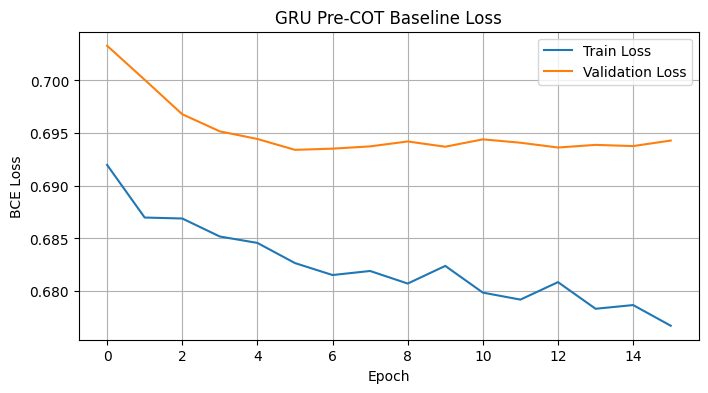

In [105]:
# Train final Pre-COT GRU on train and validate on validation

X_train_scaled_pre, X_val_scaled_pre, seq_scaler_pre = fit_transform_sequence_scaler(
    X_train_seq_pre,
    X_val_seq_pre
)

_, X_test_scaled_pre, _ = fit_transform_sequence_scaler(
    X_train_seq_pre,
    X_test_seq_pre
)

dropout_pre = 0.2 if int(best_params_pre["num_layers"]) > 1 else 0.0

gru_pre_cot_model = train_gru(
    X_train=X_train_scaled_pre,
    y_train=y_train_seq_pre,
    X_val=X_val_scaled_pre,
    y_val=y_val_seq_pre,
    hidden_size=int(best_params_pre["hidden_size"]),
    num_layers=int(best_params_pre["num_layers"]),
    dropout=dropout_pre,
    learning_rate=float(best_params_pre["learning_rate"]),
    batch_size=int(best_params_pre["batch_size"]),
    num_epochs=75,
    patience=10,
    random_state=42,
    verbose=True
)

plot_gru_losses(gru_pre_cot_model, "GRU Pre-COT Baseline Loss")

## 30. Generate Pre-COT GRU Predictions

Predictions are generated in the same format as the other GRU versions so classification and strategy results can be compared directly.

In [106]:
# Generate predictions

train_prob_pre = predict_gru_proba(gru_pre_cot_model, X_train_scaled_pre)
val_prob_pre = predict_gru_proba(gru_pre_cot_model, X_val_scaled_pre)
test_prob_pre = predict_gru_proba(gru_pre_cot_model, X_test_scaled_pre)

gru_train_preds_pre = make_gru_prediction_output(
    train_meta_pre,
    train_prob_pre,
    "gru",
    "pre_cot_baseline",
    "train"
)

gru_val_preds_pre = make_gru_prediction_output(
    val_meta_pre,
    val_prob_pre,
    "gru",
    "pre_cot_baseline",
    "val"
)

gru_test_preds_pre = make_gru_prediction_output(
    test_meta_pre,
    test_prob_pre,
    "gru",
    "pre_cot_baseline",
    "test"
)

In [107]:
# Save predictions

os.makedirs("results/predictions", exist_ok=True)

gru_train_preds_pre.to_csv(
    "results/predictions/gru_pre_cot_baseline_train_predictions.csv",
    index=False
)

gru_val_preds_pre.to_csv(
    "results/predictions/gru_pre_cot_baseline_val_predictions.csv",
    index=False
)

gru_test_preds_pre.to_csv(
    "results/predictions/gru_pre_cot_baseline_test_predictions.csv",
    index=False
)

In [109]:
# Probability diagnostics

gru_val_preds_pre[["prob_up", "pred", "Target", "returns", "vol_20"]].describe()

,prob_up,pred,Target,returns,vol_20
count,518.000000,518.0,518.000000,518.000000,518.000000
mean,0.567139,1.0,0.528958,-0.000298,0.024290
std,0.029387,0.0,0.499643,0.025769,0.008701
min,0.513941,1.0,0.000000,-0.134360,0.008609
25%,0.546214,1.0,0.000000,-0.015524,0.019349
50%,0.565620,1.0,1.000000,0.001631,0.022910
75%,0.580697,1.0,1.000000,0.016634,0.027457
max,0.652661,1.0,1.000000,0.082612,0.055159


In [110]:
# Probability diagnostics

gru_val_preds_pre[["prob_up", "pred", "Target", "returns", "vol_20"]].describe()

,prob_up,pred,Target,returns,vol_20
count,518.000000,518.0,518.000000,518.000000,518.000000
mean,0.567139,1.0,0.528958,-0.000298,0.024290
std,0.029387,0.0,0.499643,0.025769,0.008701
min,0.513941,1.0,0.000000,-0.134360,0.008609
25%,0.546214,1.0,0.000000,-0.015524,0.019349
50%,0.565620,1.0,1.000000,0.001631,0.022910
75%,0.580697,1.0,1.000000,0.016634,0.027457
max,0.652661,1.0,1.000000,0.082612,0.055159


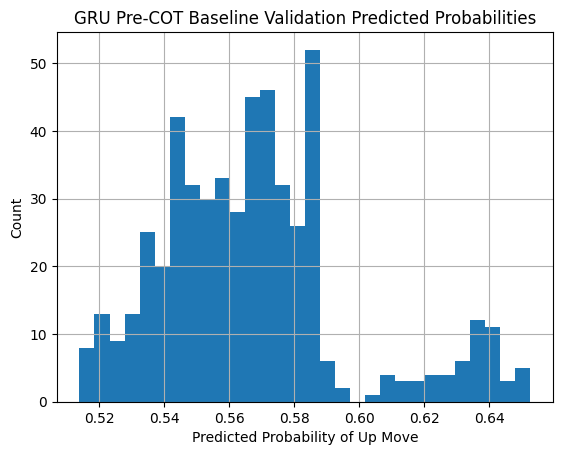

In [111]:
plt.hist(gru_val_preds_pre["prob_up"], bins=30)
plt.title("GRU Pre-COT Baseline Validation Predicted Probabilities")
plt.xlabel("Predicted Probability of Up Move")
plt.ylabel("Count")
plt.grid(True)
plt.show()

The validation and test classification reports evaluate the pre-COT GRU's directional prediction performance.

In [112]:
# Classification metrics

classification_report_simple(gru_val_preds_pre)

{'accuracy': 0.528957528957529,
 'precision': 0.528957528957529,
 'recall': 1.0,
 'f1': 0.6919191919191919,
 'roc_auc': 0.5276115831039847,
 'confusion_matrix': array([[  0, 244],
        [  0, 274]], dtype=int64)}

In [113]:
classification_report_simple(gru_test_preds_pre)

{'accuracy': 0.5021551724137931,
 'precision': 0.5021551724137931,
 'recall': 1.0,
 'f1': 0.6685796269727403,
 'roc_auc': 0.4871709120636159,
 'confusion_matrix': array([[  0, 231],
        [  0, 233]], dtype=int64)}

The pre-COT validation predictions are converted into trading positions using the same strategy rules as the other GRU versions.

In [176]:
# Trading metrics

gru_val_strategy_pre = apply_probability_vol_strategy(gru_val_preds_pre)

gru_metrics_pre = pd.DataFrame({
    "GRU Pre-COT Baseline Strategy Val": strategy_metrics(
        gru_val_strategy_pre,
        "net_strategy_return"
    ),
    "Buy & Hold Val": strategy_metrics(
        gru_val_strategy_pre,
        "buy_hold_return"
    )
}).T

gru_metrics_pre

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
GRU Pre-COT Baseline Strategy Val,-0.011310,-0.005529,0.070457,-0.078471,-0.117192,0.180311,0.180311,0.006969
Buy & Hold Val,-0.279903,-0.147641,0.409072,-0.360916,-0.509424,1.000000,1.000000,0.000000


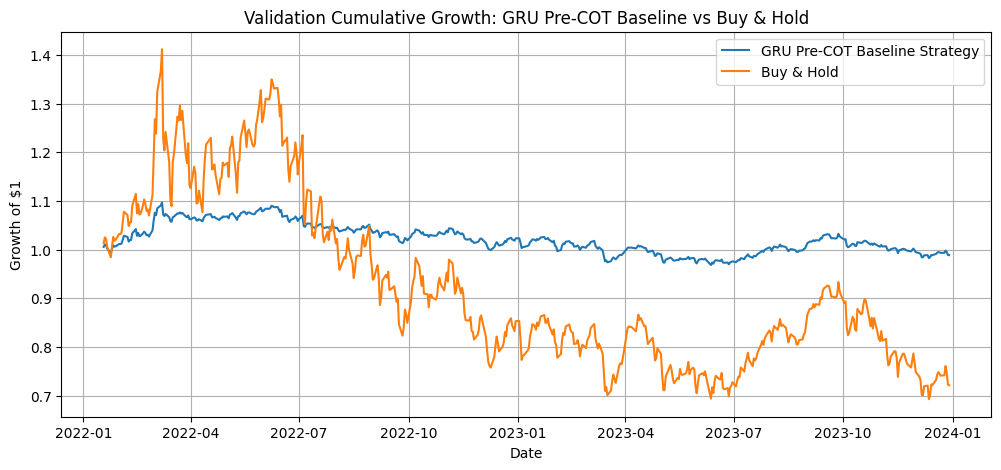

In [115]:
# Cumulative growth plot

plot_df_pre = gru_val_strategy_pre.dropna(subset=["net_strategy_return"]).copy()

plot_df_pre["cum_strategy"] = (1 + plot_df_pre["net_strategy_return"]).cumprod()
plot_df_pre["cum_buy_hold"] = (1 + plot_df_pre["buy_hold_return"]).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(
    plot_df_pre["Date"],
    plot_df_pre["cum_strategy"],
    label="GRU Pre-COT Baseline Strategy"
)
plt.plot(
    plot_df_pre["Date"],
    plot_df_pre["cum_buy_hold"],
    label="Buy & Hold"
)
plt.legend()
plt.title("Validation Cumulative Growth: GRU Pre-COT Baseline vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

The pre-COT bucket analysis checks whether its predicted probabilities are directionally meaningful across probability ranges.

In [116]:
# Bucket test

gru_val_bucket_pre = gru_val_preds_pre.copy()

gru_val_bucket_pre["bucket"] = pd.cut(
    gru_val_bucket_pre["prob_up"],
    bins=10
)

gru_bucket_stats_pre = gru_val_bucket_pre.groupby(
    "bucket",
    observed=False
).agg({
    "returns": "mean",
    "Target": "mean",
    "prob_up": "mean"
})

gru_bucket_stats_pre

,returns,Target,prob_up
bucket,,,
"(0.514, 0.528]",-0.000222,0.466667,0.521124
"(0.528, 0.542]",0.000540,0.534483,0.535140
"(0.542, 0.556]",-0.001499,0.509615,0.547752
"(0.556, 0.569]",-0.001235,0.509434,0.563023
"(0.569, 0.583]",0.001028,0.557692,0.575599
"(0.583, 0.597]",-0.002572,0.533333,0.586422
"(0.597, 0.611]",0.016963,0.600000,0.607937
"(0.611, 0.625]",-0.016713,0.400000,0.619005
"(0.625, 0.639]",0.010841,0.590909,0.633523


In [177]:
# Optional comparison table, if these metric objects already exist

gru_all_metrics = pd.concat([
    gru_metrics_pre,
    metrics,
    gru_metrics_2,
    gru_metrics_3
])

gru_all_metrics

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
GRU Pre-COT Baseline Strategy Val,-0.011310,-0.005529,0.070457,-0.078471,-0.117192,0.180311,0.180311,0.006969
Buy & Hold Val,-0.279903,-0.147641,0.409072,-0.360916,-0.509424,1.000000,1.000000,0.000000
GRU Strategy Val,0.011163,0.005426,0.071044,0.076369,-0.116825,0.163978,0.163978,0.009110
Buy & Hold Val,-0.279903,-0.147641,0.409072,-0.360916,-0.509424,1.000000,1.000000,0.000000
GRU Regime-Feature Strategy Val,0.017646,0.008562,0.067732,0.126415,-0.105835,0.162841,0.162841,0.009016
Buy & Hold Val,-0.279903,-0.147641,0.409072,-0.360916,-0.509424,1.000000,1.000000,0.000000
GRU Regime-Specific Strategy Val,0.023787,0.012015,0.051951,0.231279,-0.052938,0.136610,0.137013,0.008179
Buy & Hold Val,-0.268484,-0.146594,0.390858,-0.375057,-0.497178,1.000000,1.000000,0.000000


# Final GRU Test Runs

After comparing model versions on the validation period, I perform final test evaluation. Each final GRU version is retrained on the combined train and validation data, then evaluated once on the held-out test set.

The same trading-strategy parameters are applied to all final GRU versions so that differences in performance come from the model predictions rather than from model-specific strategy tuning.

## 31. Define Final Tuned Trading Strategy

This function converts final predicted probabilities into trading positions. The final strategy uses the same parameter values across all GRU versions: a signal multiplier, probability thresholds, asymmetric long/short scaling, nonlinear signal shaping, volatility targeting, position clipping, and transaction costs.

Strategy returns use the previous day's position multiplied by the current day's realized return, which avoids look-ahead bias.

In [121]:
final_strategy_params = {
    "signal_multiplier": 3.5,
    "long_threshold": 0.50,
    "short_threshold": 0.50,
    "alpha": 3.0,
    "beta": 1.55,
    "gamma": 0.7,
    "target_annual_vol": 0.28
}

def apply_probability_vol_strategy_tuned(
    preds,
    signal_multiplier=3.5,
    long_threshold=0.50,
    short_threshold=0.50,
    target_annual_vol=0.28,
    vol_col="vol_20",
    transaction_cost=0.0005,
    vol_floor=0.005,
    alpha=3.0,
    beta=1.55,
    gamma=0.7,
    max_position=1.0
):
    df = preds.copy()

    prob = df["prob_up"]

    raw_signal = np.zeros(len(df))

    long_mask = prob >= long_threshold
    short_mask = prob <= short_threshold

    raw_signal[long_mask] = signal_multiplier * (prob[long_mask] - long_threshold)
    raw_signal[short_mask] = signal_multiplier * (prob[short_mask] - short_threshold)

    raw_signal = np.where(
        raw_signal >= 0,
        alpha * raw_signal,
        beta * raw_signal
    )

    raw_signal = np.sign(raw_signal) * (np.abs(raw_signal) ** gamma)

    target_daily_vol = target_annual_vol / np.sqrt(252)
    adjusted_vol = df[vol_col].clip(lower=vol_floor)
    
    df["position"] = raw_signal * (target_daily_vol / adjusted_vol)
    df["position"] = df["position"].clip(-max_position, max_position)

    df["turnover"] = (df["position"] - df["position"].shift(1)).abs()

    df["gross_strategy_return"] = df["position"].shift(1) * df["returns"]
    df["net_strategy_return"] = (
        df["gross_strategy_return"] - transaction_cost * df["turnover"]
    )

    df["buy_hold_return"] = df["returns"]

    return df

## 32. Final Test Run: Pre-COT GRU

The pre-COT GRU is retrained on the combined train and validation periods using the selected hyperparameters, then evaluated on the held-out test set. This represents the final performance of the macro/price feature set before adding CFTC/COT positioning data.

In [182]:
trainval_df_pre = pd.concat([train_df_pre, val_df_pre], axis=0).copy()

trainval_df_pre["Date"] = pd.to_datetime(trainval_df_pre["Date"])
test_df_pre["Date"] = pd.to_datetime(test_df_pre["Date"])

trainval_df_pre = trainval_df_pre.sort_values("Date").reset_index(drop=True)
test_df_pre = test_df_pre.sort_values("Date").reset_index(drop=True)

X_trainval_seq_pre, y_trainval_seq_pre, trainval_meta_pre = make_sequences(
    trainval_df_pre,
    feature_cols_pre,
    target_col,
    lookback
)

X_test_seq_pre_final, y_test_seq_pre_final, test_meta_pre_final = make_sequences(
    test_df_pre,
    feature_cols_pre,
    target_col,
    lookback
)

X_trainval_scaled_pre, X_test_scaled_pre_final, seq_scaler_pre_final = fit_transform_sequence_scaler(
    X_trainval_seq_pre,
    X_test_seq_pre_final
)

dropout_pre = 0.2 if int(best_params_pre["num_layers"]) > 1 else 0.0

gru_pre_cot_final_model = train_gru(
    X_train=X_trainval_scaled_pre,
    y_train=y_trainval_seq_pre,
    X_val=None,
    y_val=None,
    hidden_size=int(best_params_pre["hidden_size"]),
    num_layers=int(best_params_pre["num_layers"]),
    dropout=dropout_pre,
    learning_rate=float(best_params_pre["learning_rate"]),
    batch_size=int(best_params_pre["batch_size"]),
    num_epochs=100,
    patience=12,
    random_state=42,
    verbose=True
)

test_prob_pre_final = predict_gru_proba(
    gru_pre_cot_final_model,
    X_test_scaled_pre_final
)

gru_test_preds_pre_final = make_gru_prediction_output(
    test_meta_pre_final,
    test_prob_pre_final,
    "gru",
    "pre_cot_baseline_final_trainval",
    "test"
)

gru_test_preds_pre_final.to_csv(
    "results/final_test_predictions/gru_pre_cot_baseline_final_test_predictions.csv",
    index=False
)

classification_report_simple(gru_test_preds_pre_final)

gru_test_strategy_pre_final = apply_probability_vol_strategy_tuned(
    gru_test_preds_pre_final,
    **final_strategy_params
)

gru_pre_final_test_metrics = pd.DataFrame({
    "GRU Pre-COT Final Test Strategy": strategy_metrics(
        gru_test_strategy_pre_final,
        "net_strategy_return"
    ),
    "Buy & Hold Final Test": strategy_metrics(
        gru_test_strategy_pre_final,
        "buy_hold_return"
    )
}).T

gru_pre_final_test_metrics

Epoch 1/100 | Train Loss: 0.6953
Epoch 2/100 | Train Loss: 0.6887
Epoch 3/100 | Train Loss: 0.6883
Epoch 4/100 | Train Loss: 0.6876
Epoch 5/100 | Train Loss: 0.6856
Epoch 6/100 | Train Loss: 0.6846
Epoch 7/100 | Train Loss: 0.6843
Epoch 8/100 | Train Loss: 0.6835
Epoch 9/100 | Train Loss: 0.6839
Epoch 10/100 | Train Loss: 0.6834
Epoch 11/100 | Train Loss: 0.6831
Epoch 12/100 | Train Loss: 0.6824
Epoch 13/100 | Train Loss: 0.6814
Epoch 14/100 | Train Loss: 0.6810
Epoch 15/100 | Train Loss: 0.6813
Epoch 16/100 | Train Loss: 0.6810
Epoch 17/100 | Train Loss: 0.6795
Epoch 18/100 | Train Loss: 0.6790
Epoch 19/100 | Train Loss: 0.6786
Epoch 20/100 | Train Loss: 0.6788
Epoch 21/100 | Train Loss: 0.6762
Epoch 22/100 | Train Loss: 0.6768
Epoch 23/100 | Train Loss: 0.6767
Epoch 24/100 | Train Loss: 0.6765
Epoch 25/100 | Train Loss: 0.6760
Epoch 26/100 | Train Loss: 0.6739
Epoch 27/100 | Train Loss: 0.6745
Epoch 28/100 | Train Loss: 0.6738
Epoch 29/100 | Train Loss: 0.6715
Epoch 30/100 | Train Lo

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
GRU Pre-COT Final Test Strategy,0.227337,0.117946,0.199934,0.589924,-0.207920,-0.545491,0.602465,0.067082
Buy & Hold Final Test,-0.225965,-0.129867,0.299023,-0.434305,-0.381141,1.000000,1.000000,0.000000


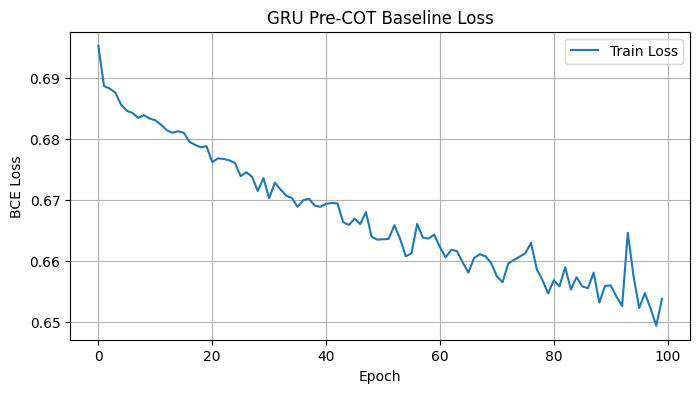

In [183]:
plot_gru_losses(gru_pre_cot_final_model, "GRU Pre-COT Baseline Loss")

In [184]:
classification_report_simple(gru_test_preds_pre_final)

{'accuracy': 0.5172413793103449,
 'precision': 0.6285714285714286,
 'recall': 0.0944206008583691,
 'f1': 0.16417910447761194,
 'roc_auc': 0.5305166936068224,
 'confusion_matrix': array([[218,  13],
        [211,  22]], dtype=int64)}

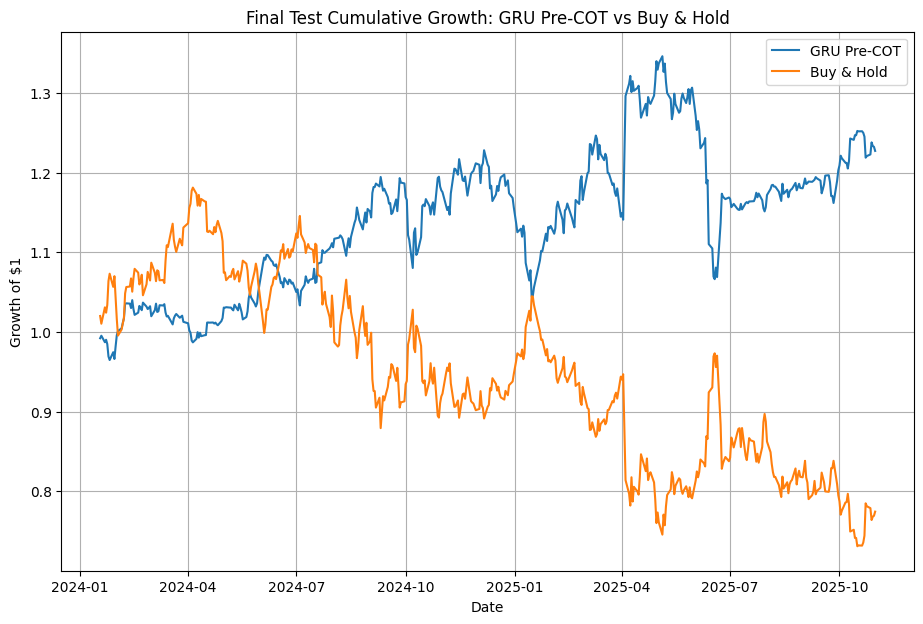

In [207]:
def plot_final_strategy_growth(strategy_df, label):
    plot_df = strategy_df.dropna(subset=["net_strategy_return"]).copy()

    plot_df["cum_strategy"] = (1 + plot_df["net_strategy_return"]).cumprod()
    plot_df["cum_buy_hold"] = (1 + plot_df["buy_hold_return"]).cumprod()

    plt.figure(figsize=(11, 7))
    plt.plot(plot_df["Date"], plot_df["cum_strategy"], label=label)
    plt.plot(plot_df["Date"], plot_df["cum_buy_hold"], label="Buy & Hold")
    plt.legend()
    plt.title(f"Final Test Cumulative Growth: {label} vs Buy & Hold")
    plt.xlabel("Date")
    plt.ylabel("Growth of $1")
    plt.grid(True)
    plt.show()

plot_final_strategy_growth(gru_test_strategy_pre_final, "GRU Pre-COT")

## 33. Final Test Run: COT-Augmented Baseline GRU

This final model uses the COT-augmented feature set but does not include HMM regime features. It is retrained on train plus validation data and evaluated on the held-out test set.

In [187]:
trainval_df = pd.concat([train_df, val_df], axis=0).copy()

trainval_df["Date"] = pd.to_datetime(trainval_df["Date"])
test_df["Date"] = pd.to_datetime(test_df["Date"])

trainval_df = trainval_df.sort_values("Date").reset_index(drop=True)
test_df = test_df.sort_values("Date").reset_index(drop=True)

X_trainval_seq, y_trainval_seq, trainval_meta = make_sequences(
    trainval_df,
    feature_cols,
    target_col,
    lookback
)

X_test_seq_final, y_test_seq_final, test_meta_final = make_sequences(
    test_df,
    feature_cols,
    target_col,
    lookback
)

X_trainval_scaled, X_test_scaled_final, seq_scaler_final = fit_transform_sequence_scaler(
    X_trainval_seq,
    X_test_seq_final
)


gru_baseline_final_model = train_gru(
    X_train=X_trainval_scaled,
    y_train=y_trainval_seq,
    X_val=None,
    y_val=None,
    hidden_size=64,
    num_layers=2,
    dropout=0.2,
    learning_rate=0.0005,
    batch_size=32,
    num_epochs=100,
    patience=12,
    random_state=42,
    verbose=True
)

test_prob_final = predict_gru_proba(
    gru_baseline_final_model,
    X_test_scaled_final
)

gru_test_preds_final = make_gru_prediction_output(
    test_meta_final,
    test_prob_final,
    "gru",
    "baseline_final_trainval",
    "test"
)

gru_test_preds_final.to_csv(
    "results/final_test_predictions/gru_baseline_final_test_predictions.csv",
    index=False
)

gru_test_strategy_final = apply_probability_vol_strategy_tuned(
    gru_test_preds_final,
    **final_strategy_params
)

gru_final_test_metrics = pd.DataFrame({
    "GRU Baseline Final Test Strategy": strategy_metrics(
        gru_test_strategy_final,
        "net_strategy_return"
    ),
    "Buy & Hold Final Test": strategy_metrics(
        gru_test_strategy_final,
        "buy_hold_return"
    )
}).T

gru_final_test_metrics

Epoch 1/100 | Train Loss: 0.6994
Epoch 2/100 | Train Loss: 0.6894
Epoch 3/100 | Train Loss: 0.6874
Epoch 4/100 | Train Loss: 0.6854
Epoch 5/100 | Train Loss: 0.6835
Epoch 6/100 | Train Loss: 0.6824
Epoch 7/100 | Train Loss: 0.6812
Epoch 8/100 | Train Loss: 0.6806
Epoch 9/100 | Train Loss: 0.6787
Epoch 10/100 | Train Loss: 0.6788
Epoch 11/100 | Train Loss: 0.6784
Epoch 12/100 | Train Loss: 0.6770
Epoch 13/100 | Train Loss: 0.6794
Epoch 14/100 | Train Loss: 0.6846
Epoch 15/100 | Train Loss: 0.6867
Epoch 16/100 | Train Loss: 0.6798
Epoch 17/100 | Train Loss: 0.6754
Epoch 18/100 | Train Loss: 0.6755
Epoch 19/100 | Train Loss: 0.6726
Epoch 20/100 | Train Loss: 0.6722
Epoch 21/100 | Train Loss: 0.6722
Epoch 22/100 | Train Loss: 0.6697
Epoch 23/100 | Train Loss: 0.6714
Epoch 24/100 | Train Loss: 0.6699
Epoch 25/100 | Train Loss: 0.6765
Epoch 26/100 | Train Loss: 0.6730
Epoch 27/100 | Train Loss: 0.6690
Epoch 28/100 | Train Loss: 0.6669
Epoch 29/100 | Train Loss: 0.6696
Epoch 30/100 | Train Lo

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
GRU Baseline Final Test Strategy,-0.070838,-0.039200,0.255200,-0.153607,-0.470833,0.004604,0.862879,0.580959
Buy & Hold Final Test,-0.225965,-0.129867,0.299023,-0.434305,-0.381141,1.000000,1.000000,0.000000


In [188]:
classification_report_simple(gru_test_preds_final)

{'accuracy': 0.5064655172413793,
 'precision': 0.509009009009009,
 'recall': 0.48497854077253216,
 'f1': 0.4967032967032967,
 'roc_auc': 0.5053601620125225,
 'confusion_matrix': array([[122, 109],
        [120, 113]], dtype=int64)}

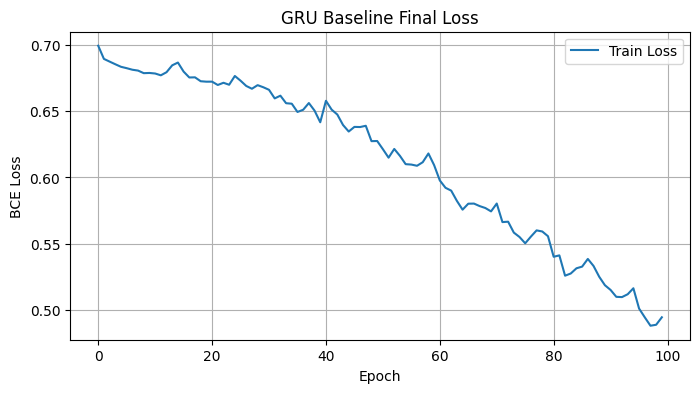

In [189]:
plot_gru_losses(gru_baseline_final_model, "GRU Baseline Final Loss")

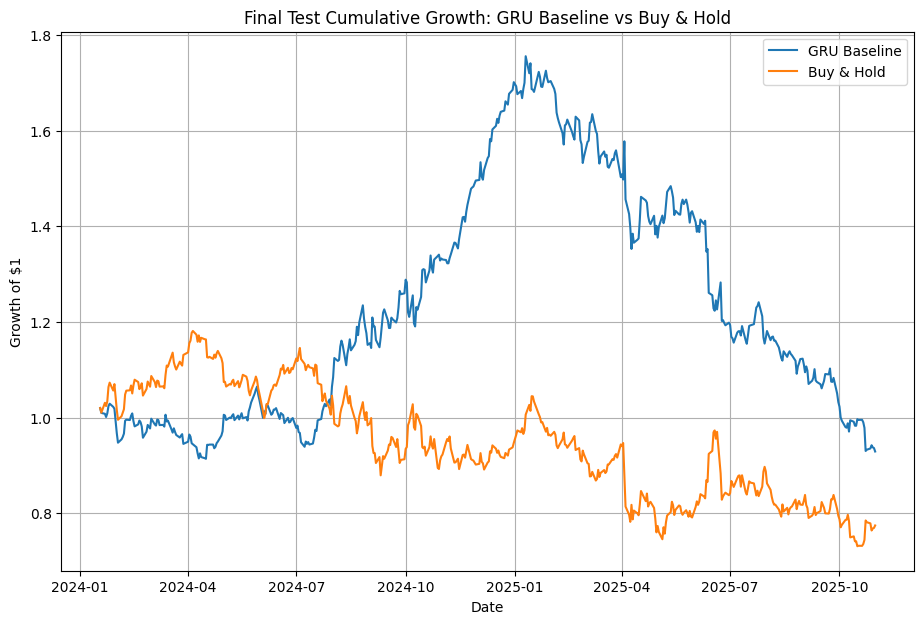

In [208]:
plot_final_strategy_growth(gru_test_strategy_final, "GRU Baseline")

## 34. Final Test Run: Regime-Feature GRU

The regime-feature GRU uses HMM regime probabilities as additional predictors in one global sequence model. It is retrained on train plus validation data and evaluated on the held-out test set.

In [191]:
trainval_df_2 = pd.concat([train_df_2, val_df_2], axis=0).copy()

trainval_df_2["Date"] = pd.to_datetime(trainval_df_2["Date"])
test_df_2["Date"] = pd.to_datetime(test_df_2["Date"])

trainval_df_2 = trainval_df_2.sort_values("Date").reset_index(drop=True)
test_df_2 = test_df_2.sort_values("Date").reset_index(drop=True)

print("Regime prob columns used:")
print([c for c in feature_cols_2 if "regime_prob" in c])

X_trainval_seq_2, y_trainval_seq_2, trainval_meta_2 = make_sequences(
    trainval_df_2,
    feature_cols_2,
    target_col,
    lookback
)

X_test_seq_2_final, y_test_seq_2_final, test_meta_2_final = make_sequences(
    test_df_2,
    feature_cols_2,
    target_col,
    lookback
)

X_trainval_scaled_2, X_test_scaled_2_final, seq_scaler_2_final = fit_transform_sequence_scaler(
    X_trainval_seq_2,
    X_test_seq_2_final
)


gru_regime_feature_final_model = train_gru(
    X_train=X_trainval_scaled_2,
    y_train=y_trainval_seq_2,
    X_val=None,
    y_val=None,
    hidden_size=64,
    num_layers=1,
    dropout=0.2,
    learning_rate=0.0005,
    batch_size=64,
    num_epochs=100,
    patience=12,
    random_state=42,
    verbose=True
)

test_prob_2_final = predict_gru_proba(
    gru_regime_feature_final_model,
    X_test_scaled_2_final
)

gru_test_preds_2_final = make_gru_prediction_output(
    test_meta_2_final,
    test_prob_2_final,
    "gru",
    "regime_feature_final_trainval",
    "test"
)

gru_test_preds_2_final.to_csv(
    "results/final_test_predictions/gru_regime_feature_final_test_predictions.csv",
    index=False
)


gru_test_strategy_2_final = apply_probability_vol_strategy_tuned(
    gru_test_preds_2_final,
    **final_strategy_params
)

gru_2_final_test_metrics = pd.DataFrame({
    "GRU Regime-Feature Final Test Strategy": strategy_metrics(
        gru_test_strategy_2_final,
        "net_strategy_return"
    ),
    "Buy & Hold Final Test": strategy_metrics(
        gru_test_strategy_2_final,
        "buy_hold_return"
    )
}).T

gru_2_final_test_metrics

Regime prob columns used:
['regime_prob_0', 'regime_prob_1', 'regime_prob_2']
Epoch 1/100 | Train Loss: 0.7034
Epoch 2/100 | Train Loss: 0.6894
Epoch 3/100 | Train Loss: 0.6862
Epoch 4/100 | Train Loss: 0.6843
Epoch 5/100 | Train Loss: 0.6828
Epoch 6/100 | Train Loss: 0.6816
Epoch 7/100 | Train Loss: 0.6806
Epoch 8/100 | Train Loss: 0.6796
Epoch 9/100 | Train Loss: 0.6788
Epoch 10/100 | Train Loss: 0.6779
Epoch 11/100 | Train Loss: 0.6774
Epoch 12/100 | Train Loss: 0.6770
Epoch 13/100 | Train Loss: 0.6776
Epoch 14/100 | Train Loss: 0.6793
Epoch 15/100 | Train Loss: 0.6834
Epoch 16/100 | Train Loss: 0.6857
Epoch 17/100 | Train Loss: 0.6828
Epoch 18/100 | Train Loss: 0.6778
Epoch 19/100 | Train Loss: 0.6746
Epoch 20/100 | Train Loss: 0.6725
Epoch 21/100 | Train Loss: 0.6713
Epoch 22/100 | Train Loss: 0.6699
Epoch 23/100 | Train Loss: 0.6691
Epoch 24/100 | Train Loss: 0.6679
Epoch 25/100 | Train Loss: 0.6675
Epoch 26/100 | Train Loss: 0.6668
Epoch 27/100 | Train Loss: 0.6676
Epoch 28/100 

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
GRU Regime-Feature Final Test Strategy,-0.155908,-0.088124,0.260486,-0.338307,-0.247868,-0.217582,0.841656,0.500535
Buy & Hold Final Test,-0.225965,-0.129867,0.299023,-0.434305,-0.381141,1.000000,1.000000,0.000000


In [192]:
classification_report_simple(gru_test_preds_2_final)

{'accuracy': 0.4956896551724138,
 'precision': 0.49700598802395207,
 'recall': 0.3562231759656652,
 'f1': 0.415,
 'roc_auc': 0.5090017278858481,
 'confusion_matrix': array([[147,  84],
        [150,  83]], dtype=int64)}

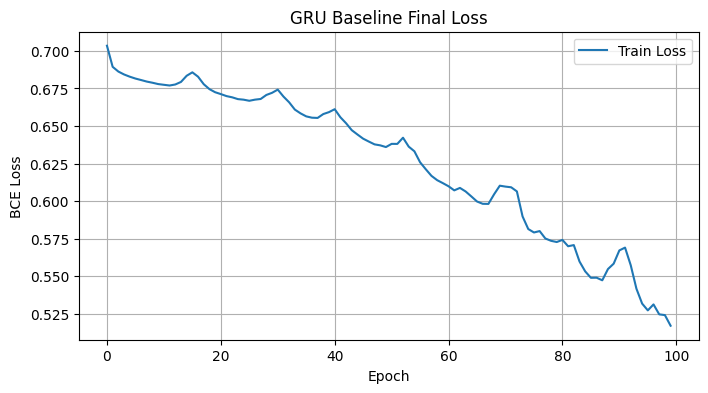

In [193]:
plot_gru_losses(gru_regime_feature_final_model, "GRU Baseline Final Loss")

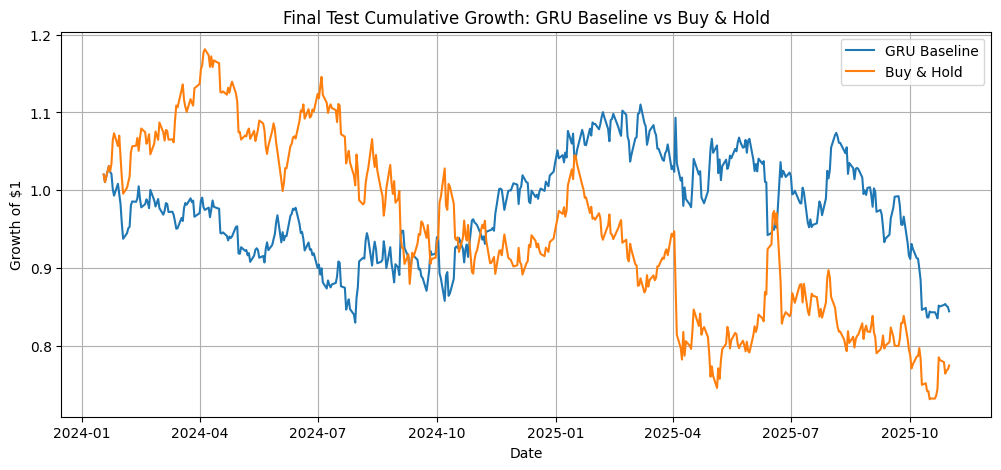

In [194]:
plot_final_strategy_growth(gru_test_strategy_2_final, "GRU Baseline")

## 35. Final Test Run: Regime-Specific GRU

The regime-specific GRU trains separate sequence models within each lagged HMM regime using the combined train and validation data. Final test predictions are generated by applying the GRU corresponding to each sequence's target-date lagged regime.

In [195]:
trainval_df_3 = pd.concat([train_df_3, val_df_3], axis=0).copy()

trainval_df_3["Date"] = pd.to_datetime(trainval_df_3["Date"])
test_df_3["Date"] = pd.to_datetime(test_df_3["Date"])

trainval_df_3 = trainval_df_3.sort_values("Date").reset_index(drop=True)
test_df_3 = test_df_3.sort_values("Date").reset_index(drop=True)

print("Train+Val regimes:")
print(trainval_df_3["regime_lag"].value_counts())

print("\nTest regimes:")
print(test_df_3["regime_lag"].value_counts())

print("\nRegime prob columns included in feature_cols_3:")
print([c for c in feature_cols_3 if "regime_prob" in c])

Train+Val regimes:
regime_lag
0.0    986
1.0    854
2.0    428
Name: count, dtype: int64

Test regimes:
regime_lag
0.0    349
1.0    124
Name: count, dtype: int64

Regime prob columns included in feature_cols_3:
[]


In [ ]:
gru_regime_models_final = {}
gru_regime_scalers_final = {}


for regime in sorted(trainval_df_3["regime_lag"].unique()):
    print(f"\nTraining final GRU model for regime {regime}")

    trainval_r = trainval_df_3[trainval_df_3["regime_lag"] == regime].copy()

    X_trainval_r, y_trainval_r, trainval_meta_r = make_sequences_for_regime(
        trainval_r,
        feature_cols_3,
        target_col,
        lookback
    )

    print("Rows before sequence:", len(trainval_r))
    print("Sequence shape:", X_trainval_r.shape)

    if len(X_trainval_r) < 20:
        print(f"Skipping regime {regime}: too few sequences")
        continue

    # For final training, fit scaler on all train+val sequences for this regime.
    n, t, f = X_trainval_r.shape
    scaler_r = StandardScaler()

    X_trainval_r_scaled = scaler_r.fit_transform(
        X_trainval_r.reshape(-1, f)
    ).reshape(n, t, f)

    model_r = train_gru(
        X_train=X_trainval_r_scaled,
        y_train=y_trainval_r,
        X_val=None,
        y_val=None,
        hidden_size=64,
        num_layers=1,
        dropout=0.2,
        learning_rate=0.0005,
        batch_size=64,
        num_epochs=100,
        patience=12,
        random_state=42,
        verbose=True
    )

    gru_regime_models_final[regime] = model_r
    gru_regime_scalers_final[regime] = scaler_r


Training final GRU model for regime 0.0
Rows before sequence: 986
Sequence shape: (976, 10, 42)
Epoch 1/100 | Train Loss: 0.6997
Epoch 2/100 | Train Loss: 0.6907
Epoch 3/100 | Train Loss: 0.6888
Epoch 4/100 | Train Loss: 0.6868
Epoch 5/100 | Train Loss: 0.6852
Epoch 6/100 | Train Loss: 0.6840
Epoch 7/100 | Train Loss: 0.6829
Epoch 8/100 | Train Loss: 0.6819
Epoch 9/100 | Train Loss: 0.6809
Epoch 10/100 | Train Loss: 0.6800
Epoch 11/100 | Train Loss: 0.6792
Epoch 12/100 | Train Loss: 0.6783
Epoch 13/100 | Train Loss: 0.6773
Epoch 14/100 | Train Loss: 0.6764
Epoch 15/100 | Train Loss: 0.6754
Epoch 16/100 | Train Loss: 0.6744
Epoch 17/100 | Train Loss: 0.6734
Epoch 18/100 | Train Loss: 0.6723
Epoch 19/100 | Train Loss: 0.6712
Epoch 20/100 | Train Loss: 0.6700
Epoch 21/100 | Train Loss: 0.6687
Epoch 22/100 | Train Loss: 0.6674
Epoch 23/100 | Train Loss: 0.6659
Epoch 24/100 | Train Loss: 0.6644
Epoch 25/100 | Train Loss: 0.6628
Epoch 26/100 | Train Loss: 0.6611
Epoch 27/100 | Train Loss: 0

In [199]:
def make_regime_specific_gru_predictions_final(
    df,
    feature_cols,
    regime_models,
    regime_scalers,
    lookback=10,
    split_name="test"
):
    pred_list = []

    for regime, model in regime_models.items():
        df_r = df[df["regime_lag"] == regime].copy()
        df_r = df_r.sort_values("Date").reset_index(drop=True)

        if len(df_r) <= lookback:
            print(f"Skipping regime {regime} in {split_name}: too few rows")
            continue

        X_r, y_r, meta_r = make_sequences_for_regime(
            df_r,
            feature_cols,
            target_col,
            lookback
        )

        scaler_r = regime_scalers[regime]

        n, t, f = X_r.shape
        X_r_scaled = scaler_r.transform(
            X_r.reshape(-1, f)
        ).reshape(n, t, f)

        probs_r = predict_gru_proba(model, X_r_scaled)

        preds_r = make_gru_prediction_output(
            meta_r,
            probs_r,
            "gru",
            "regime_specific_final_trainval",
            split_name
        )

        preds_r["regime_lag"] = regime
        pred_list.append(preds_r)

    out = pd.concat(pred_list, ignore_index=True)
    out = out.sort_values("Date").reset_index(drop=True)

    return out

In [ ]:
gru_test_preds_3_final = make_regime_specific_gru_predictions_final(
    test_df_3,
    feature_cols_3,
    gru_regime_models_final,
    gru_regime_scalers_final,
    lookback=lookback,
    split_name="test"
)

gru_test_preds_3_final.to_csv(
    "results/final_test_predictions/gru_regime_specific_final_test_predictions.csv",
    index=False
)


gru_test_strategy_3_final = apply_probability_vol_strategy_tuned(
    gru_test_preds_3_final,
    **final_strategy_params
)

gru_3_final_test_metrics = pd.DataFrame({
    "GRU Regime-Specific Final Test Strategy": strategy_metrics(
        gru_test_strategy_3_final,
        "net_strategy_return"
    ),
    "Buy & Hold Final Test": strategy_metrics(
        gru_test_strategy_3_final,
        "buy_hold_return"
    )
}).T

gru_3_final_test_metrics

Skipping regime 2.0 in test: too few rows


,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
GRU Regime-Specific Final Test Strategy,0.420314,0.216068,0.257118,0.840345,-0.142711,-0.138265,0.785168,0.35946
Buy & Hold Final Test,-0.239280,-0.141132,0.301206,-0.468555,-0.381141,1.000000,1.000000,0.00000


The classification report evaluates the final regime-specific GRU on the held-out test set.

In [ ]:
classification_report_simple(gru_test_preds_3_final)

{'accuracy': 0.5209713024282561,
 'precision': 0.5280898876404494,
 'recall': 0.41409691629955947,
 'f1': 0.4641975308641975,
 'roc_auc': 0.5130014424388912,
 'confusion_matrix': array([[142,  84],
        [133,  94]], dtype=int64)}

## 36. Final GRU Comparison

The table below combines final test-period strategy metrics for all GRU versions: pre-COT, COT-augmented baseline, regime-feature, and regime-specific.

In [204]:
gru_final_test_all_metrics = pd.concat([
    gru_pre_final_test_metrics,
    gru_final_test_metrics,
    gru_2_final_test_metrics,
    gru_3_final_test_metrics
])

gru_final_test_all_metrics

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
GRU Pre-COT Final Test Strategy,0.227337,0.117946,0.199934,0.589924,-0.207920,-0.545491,0.602465,0.067082
Buy & Hold Final Test,-0.225965,-0.129867,0.299023,-0.434305,-0.381141,1.000000,1.000000,0.000000
GRU Baseline Final Test Strategy,-0.070838,-0.039200,0.255200,-0.153607,-0.470833,0.004604,0.862879,0.580959
Buy & Hold Final Test,-0.225965,-0.129867,0.299023,-0.434305,-0.381141,1.000000,1.000000,0.000000
GRU Regime-Feature Final Test Strategy,-0.155908,-0.088124,0.260486,-0.338307,-0.247868,-0.217582,0.841656,0.500535
Buy & Hold Final Test,-0.225965,-0.129867,0.299023,-0.434305,-0.381141,1.000000,1.000000,0.000000
GRU Regime-Specific Final Test Strategy,0.420314,0.216068,0.257118,0.840345,-0.142711,-0.138265,0.785168,0.359460
Buy & Hold Final Test,-0.239280,-0.141132,0.301206,-0.468555,-0.381141,1.000000,1.000000,0.000000


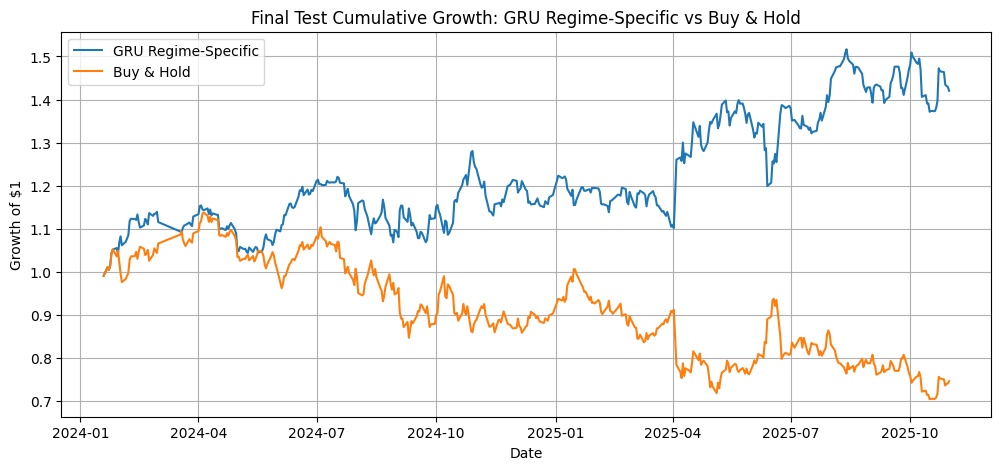

In [203]:
plot_final_strategy_growth(gru_test_strategy_3_final, "GRU Regime-Specific")